#   Texas Government Employee Salary Analysis and Prediction Using Machine Learning 

##  Business Objective

- Understand salary distribution across employees.

- Identify factors affecting employee compensation.

- Analyze wage disparities among employee groups.

- Predict employee salaries using machine learning models.

- Generate actionable business insights for workforce planning.

## 1. Import Libraries 

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns',None)

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns',None)

## 2. Load Data

In [2]:
df = pd.read_csv(r"C:\Users\vishal\OneDrive\Desktop\DataMites internship projects\Texas salary\salary.csv")

In [3]:
df.head()

,AGENCY,AGENCY NAME,LAST NAME,FIRST NAME,MI,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,EMPLOY DATE,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL,STATE NUMBER,duplicated,multiple_full_time_jobs,combined_multiple_jobs,summed_annual_salary,hide_from_search
0,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",RUCKER,MORTON,V,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,02/18/88,75.96150,29.0,9545.82,114549.84,127717,True,NaN,NaN,131407.08,NaN
1,212,OFFICE OF COURT ADMINISTRATION ...,RUCKER,MORTON,V,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,02/01/15,81.04454,4.0,1404.77,16857.24,127717,True,NaN,NaN,NaN,True
2,241,"COMPTROLLER OF PUBLIC ACCOUNTS, JUDICIARY SECT...",SPECIA JR,JOHN,J,JD25,"JUDGE, RETIRED ...",WHITE,MALE,URP - UNCLASSIFIED REGULAR PART-TIME,02/01/20,75.96150,29.0,9545.82,114549.84,59115,True,NaN,NaN,131407.08,NaN
3,212,OFFICE OF COURT ADMINISTRATION ...,SPECIA JR,JOHN,J,3524,GENERAL COUNSEL IV ...,WHITE,MALE,CTP - CLASSIFIED TEMPORARY PART-TIME,09/01/18,81.04453,4.0,1404.77,16857.24,59115,True,NaN,NaN,NaN,True
4,696,TEXAS DEPARTMENT OF CRIMINAL JUSTICE ...,ONTIVEROS,ESTHER,,4504,CORREC OFFICER IV ...,HISPANIC,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,06/29/20,0.00000,40.0,3284.27,39411.24,165030,True,1.0,NaN,NaN,NaN


## 3. columns names

In [4]:
df.columns

Index(['AGENCY', 'AGENCY NAME', 'LAST NAME', 'FIRST NAME', 'MI', 'CLASS CODE',
       'CLASS TITLE', 'ETHNICITY', 'GENDER', 'STATUS', 'EMPLOY DATE',
       'HRLY RATE', 'HRS PER WK', 'MONTHLY', 'ANNUAL', 'STATE NUMBER',
       'duplicated', 'multiple_full_time_jobs', 'combined_multiple_jobs',
       'summed_annual_salary', 'hide_from_search'],
      dtype='object')

## 4. shape

In [5]:
df.shape

(149481, 21)

## 5. Describe

In [6]:
df.describe()

,AGENCY,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL,STATE NUMBER,multiple_full_time_jobs,summed_annual_salary
count,149481.000000,149481.000000,149481.000000,149481.000000,149481.000000,1.494810e+05,14.0,16.000000
mean,545.736288,0.346488,39.714918,4226.184248,50714.210973,5.651930e+05,1.0,74303.955000
std,139.057691,4.211485,2.323855,2093.111691,25117.340292,4.786212e+05,0.0,51925.944282
min,101.000000,0.000000,1.000000,50.000000,600.000000,1.000000e+00,1.0,18000.000000
25%,529.000000,0.000000,40.000000,3019.840000,36238.080000,1.133340e+05,1.0,32962.500000
50%,530.000000,0.000000,40.000000,3720.170000,44642.040000,3.463730e+05,1.0,48063.300000
75%,696.000000,0.000000,40.000000,4865.810000,58389.720000,1.100500e+06,1.0,123751.770000
max,930.000000,117.788480,70.000000,46125.000000,553500.000000,1.271604e+06,1.0,171383.400000


## 6. Info

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149481 entries, 0 to 149480
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   AGENCY                   149481 non-null  int64  
 1   AGENCY NAME              149481 non-null  object 
 2   LAST NAME                149481 non-null  object 
 3   FIRST NAME               149481 non-null  object 
 4   MI                       149481 non-null  object 
 5   CLASS CODE               149481 non-null  object 
 6   CLASS TITLE              149481 non-null  object 
 7   ETHNICITY                149481 non-null  object 
 8   GENDER                   149481 non-null  object 
 9   STATUS                   149481 non-null  object 
 10  EMPLOY DATE              149481 non-null  object 
 11  HRLY RATE                149481 non-null  float64
 12  HRS PER WK               149481 non-null  float64
 13  MONTHLY                  149481 non-null  float64
 14  ANNU

## 7. Missing values

In [8]:
df.isnull().sum()

AGENCY                          0
AGENCY NAME                     0
LAST NAME                       0
FIRST NAME                      0
MI                              0
CLASS CODE                      0
CLASS TITLE                     0
ETHNICITY                       0
GENDER                          0
STATUS                          0
EMPLOY DATE                     0
HRLY RATE                       0
HRS PER WK                      0
MONTHLY                         0
ANNUAL                          0
STATE NUMBER                    0
duplicated                 149338
multiple_full_time_jobs    149467
combined_multiple_jobs     149384
summed_annual_salary       149465
hide_from_search           149465
dtype: int64

## 8. Missing value Percentage

In [9]:
(df.isnull().sum()/len(df))*100

AGENCY                      0.000000
AGENCY NAME                 0.000000
LAST NAME                   0.000000
FIRST NAME                  0.000000
MI                          0.000000
CLASS CODE                  0.000000
CLASS TITLE                 0.000000
ETHNICITY                   0.000000
GENDER                      0.000000
STATUS                      0.000000
EMPLOY DATE                 0.000000
HRLY RATE                   0.000000
HRS PER WK                  0.000000
MONTHLY                     0.000000
ANNUAL                      0.000000
STATE NUMBER                0.000000
duplicated                 99.904336
multiple_full_time_jobs    99.990634
combined_multiple_jobs     99.935109
summed_annual_salary       99.989296
hide_from_search           99.989296
dtype: float64

## 9. Removing Missing values

In [10]:
high_missing_cols = [
    'duplicated',
    'multiple_full_time_jobs',
    'combined_multiple_jobs',
    'summed_annual_salary',
    'hide_from_search'
]

df.drop(columns=high_missing_cols, inplace=True)

print(df.shape)

(149481, 16)


## 10. Missing Value Percentage Table

In [11]:
missing_df = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': (df.isnull().sum()/len(df))*100
})

missing_df.sort_values(
    by='Percentage',
    ascending=False
)

,Missing Values,Percentage
AGENCY,0,0.0
AGENCY NAME,0,0.0
LAST NAME,0,0.0
FIRST NAME,0,0.0
MI,0,0.0
CLASS CODE,0,0.0
CLASS TITLE,0,0.0
ETHNICITY,0,0.0
GENDER,0,0.0
STATUS,0,0.0


### Conclusion:

##### The dataset is highly clean and complete. No significant missing values were observed in the core salary-related variables.
##### Columns having more than 99% missing values were removed to improve data quality and model performance.

## 11. Duplicates

In [12]:
df.duplicated().sum()

0

## 12. TARGET DISTRIBUTION

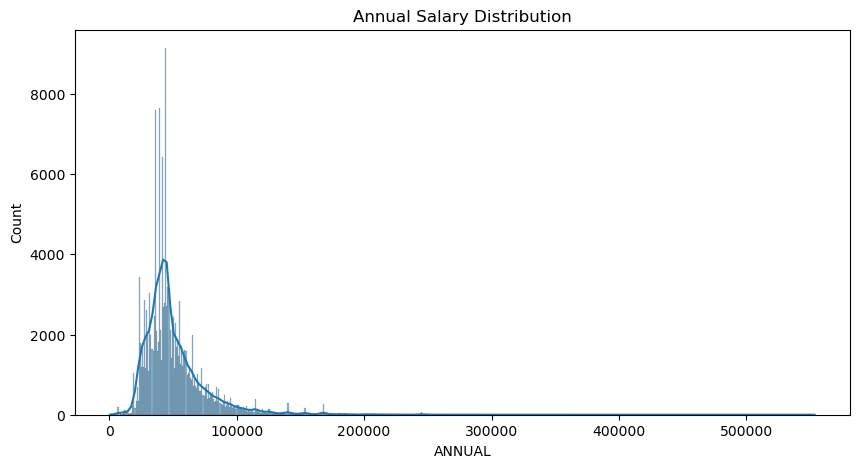

In [13]:
plt.figure(figsize=(10,5))
sns.histplot(df['ANNUAL'],kde=True)
plt.title("Annual Salary Distribution")
plt.show()

### Observation:

- Annual salary distribution is positively skewed.
- Most employees fall within the lower to mid salary ranges.
- A small number of employees receive exceptionally high salaries.
- These high-income employees contribute to the long right tail of the distribution.

## 13. MONTHLY DISTRIBUTION

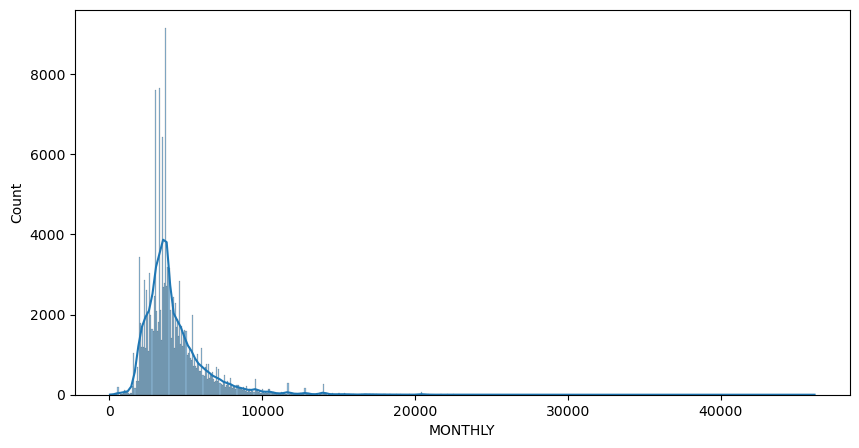

In [14]:
plt.figure(figsize=(10,5))
sns.histplot(df['MONTHLY'],kde=True)
plt.show()

### Observation:

- Monthly salary follows a similar distribution to annual salary.
- Most employees earn moderate monthly compensation.
- A few employees earn significantly higher monthly salaries.
- The distribution indicates unequal salary levels across roles.

## 14. HOURLY RATE DISTRIBUTION

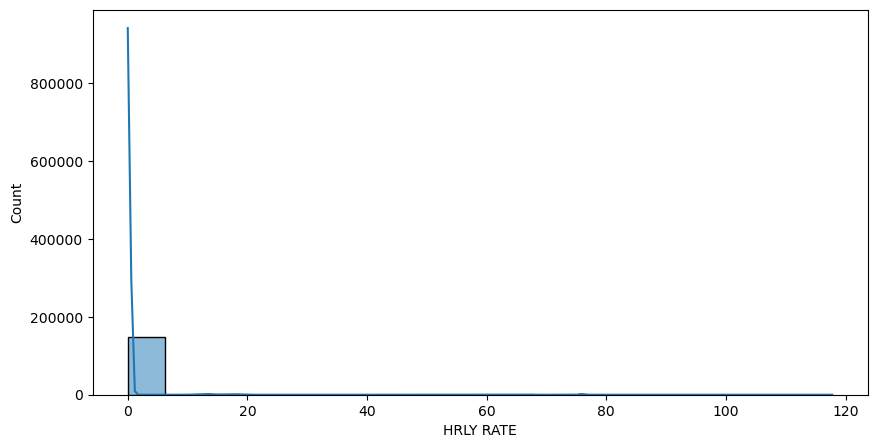

In [15]:
plt.figure(figsize=(10,5))
sns.histplot(df['HRLY RATE'],kde=True)
plt.show()

### Observation:

- Hourly rates are concentrated within a limited range.
- A small number of employees have very high hourly rates.
- The distribution suggests different pay scales across job categories.
- Higher hourly rates are generally associated with senior positions.

## 15. HOURS PER WEEK

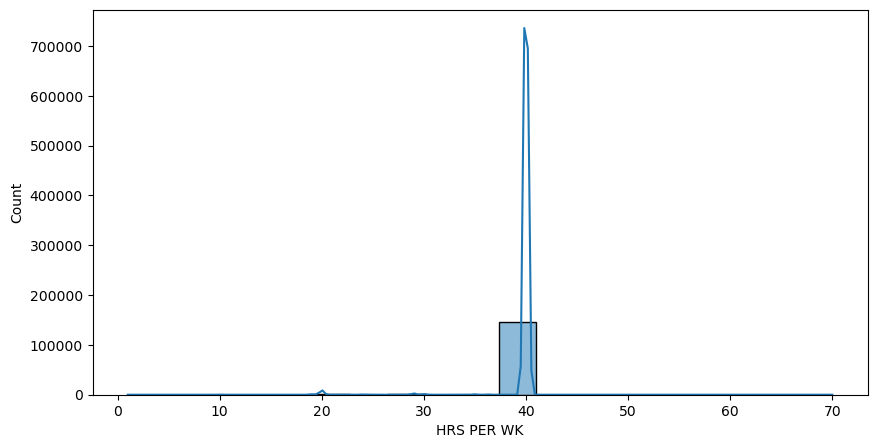

In [16]:
plt.figure(figsize=(10,5))
sns.histplot(df['HRS PER WK'],kde=True)
plt.show()

### Observation:

- Most employees work standard full-time schedules.
- Working hours are concentrated around common state employment policies.
- Only a small percentage of employees work reduced schedules.
- Workforce utilization appears consistent across agencies.

## 16. GENDER COUNT

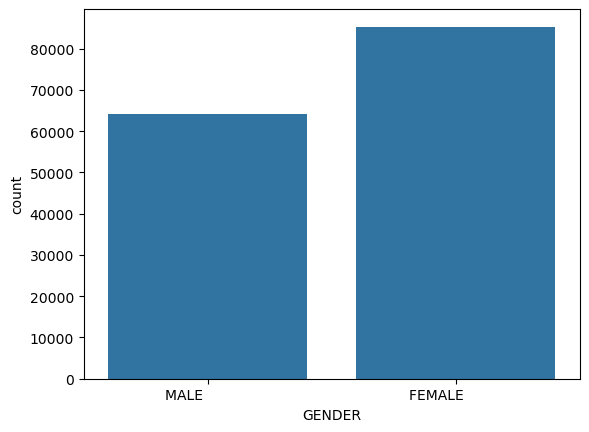

In [17]:
sns.countplot(x='GENDER',data=df)
plt.show()

### Observation:

- The workforce consists of both male and female employees.
- Gender representation may vary across departments.
- Understanding gender distribution helps evaluate workforce diversity.
- Further salary analysis can identify potential pay disparities.

## 17. ETHNICITY COUNT

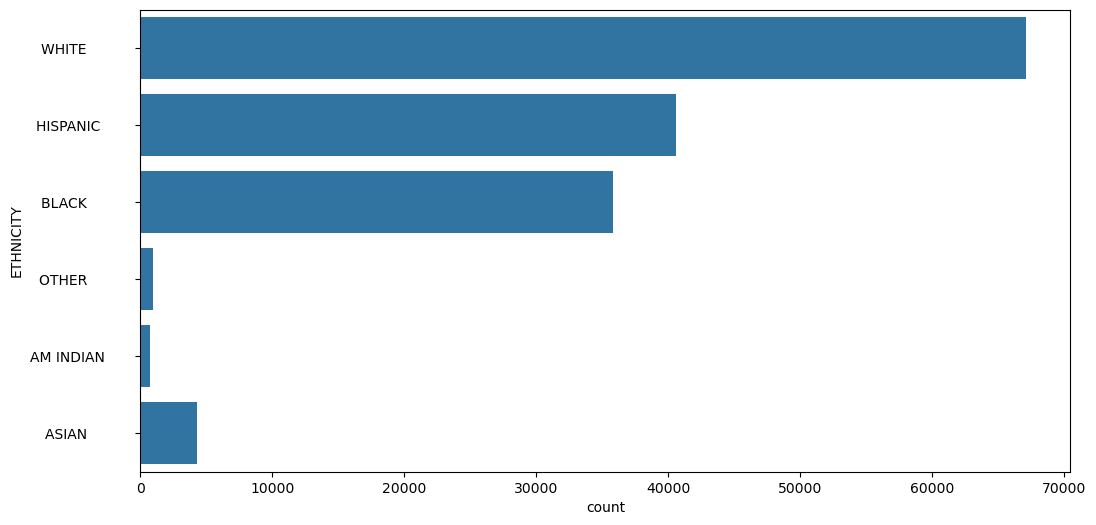

In [18]:
plt.figure(figsize=(12,6))
sns.countplot(y='ETHNICITY',data=df)
plt.show()

### Observation:

- Employees belong to multiple ethnic groups.
- Workforce diversity is evident across the state government.
- Some ethnic groups have larger representation than others.
- Further analysis can evaluate salary equity among groups.

## 18. STATUS COUNT

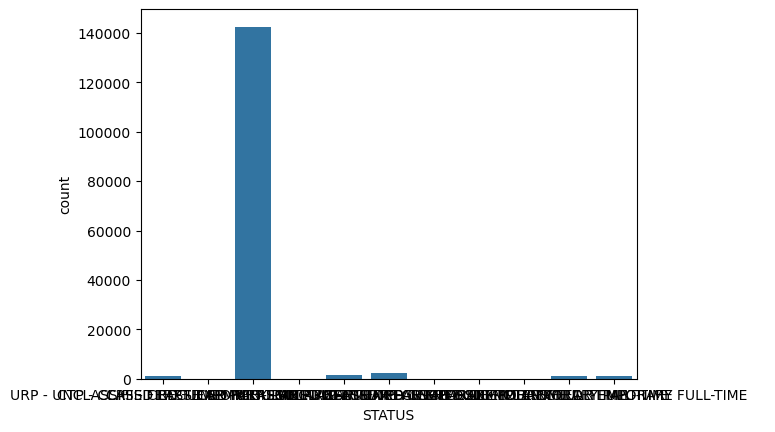

In [19]:
sns.countplot(x='STATUS',data=df)
plt.show()

## 19. TOP AGENCIES

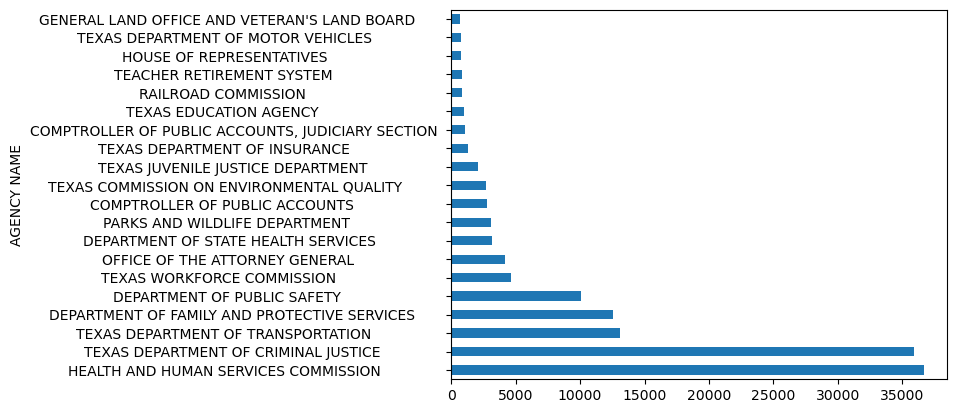

In [20]:
df['AGENCY NAME'].value_counts().head(20).plot(kind='barh')
plt.show()

## 20. TOP JOB ROLES

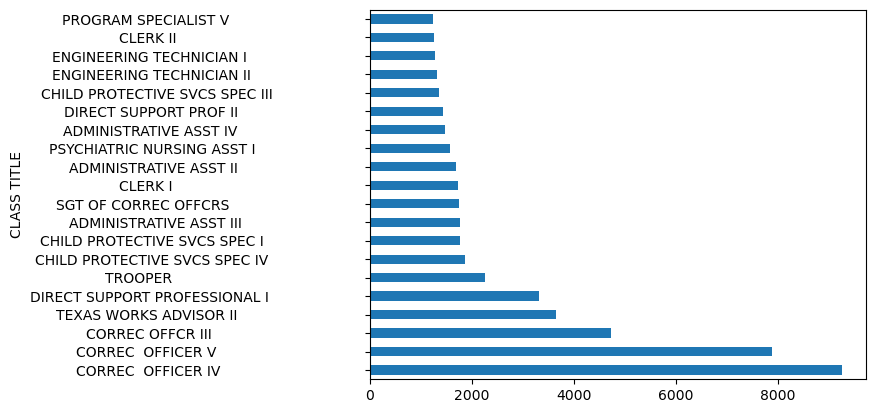

In [21]:
df['CLASS TITLE'].value_counts().head(20).plot(kind='barh')
plt.show()

## 21. SALARY BY GENDER

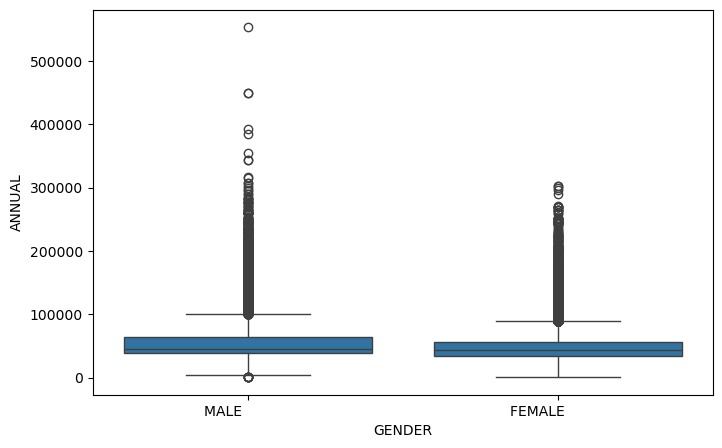

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(x='GENDER',y='ANNUAL',data=df)
plt.show()

### Observation:

- Salary distributions differ across genders.
- Median salaries appear relatively similar in some categories.
- Salary variations may result from role and experience differences.
- Further investigation can identify potential pay gaps.

## 22. SALARY BY ETHNICITY

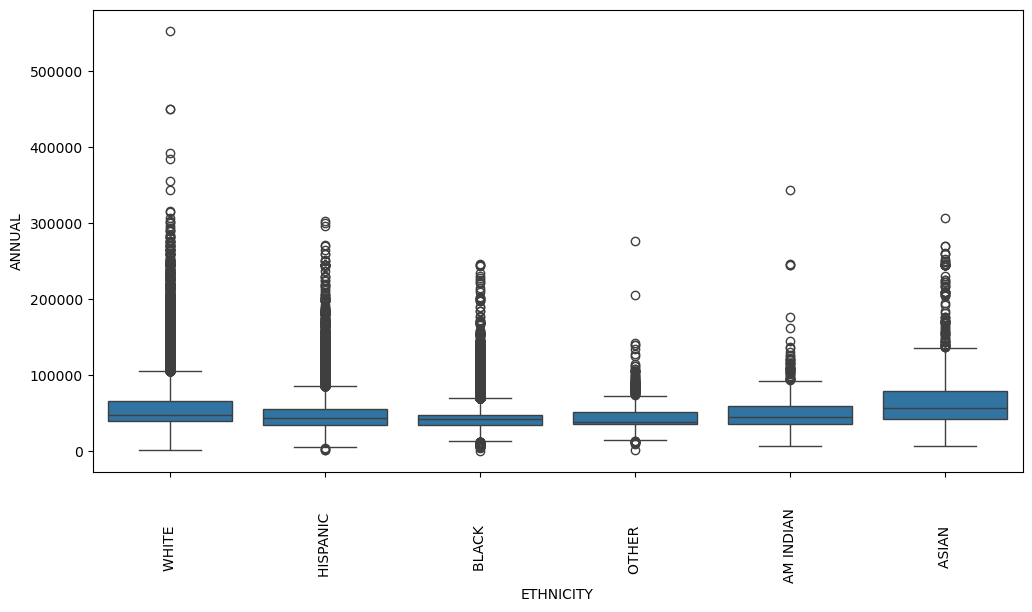

In [23]:
plt.figure(figsize=(12,6))
sns.boxplot(x='ETHNICITY',y='ANNUAL',data=df)
plt.xticks(rotation=90)
plt.show()

### Observation:

- Salary distributions vary among ethnic groups.
- Differences may reflect role composition and experience levels.
- Additional analysis is required before drawing conclusions regarding equity.
- Workforce diversity metrics should be considered alongside salary analysis.

## 23. SALARY BY STATUS

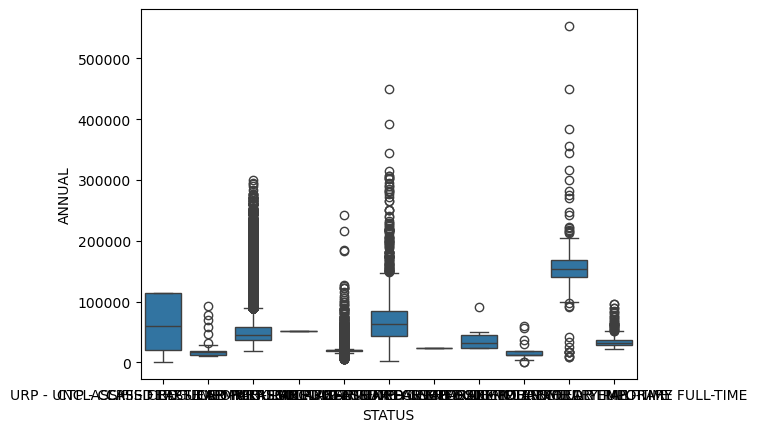

In [24]:
sns.boxplot(x='STATUS',y='ANNUAL',data=df)
plt.show()

### Observation:

- Employment status significantly impacts compensation.
- Full-time employees generally earn higher annual salaries.
- Temporary and part-time employees show lower salary distributions.
- Status is an important predictor of salary.

## 24. CORRELATION HEATMAP

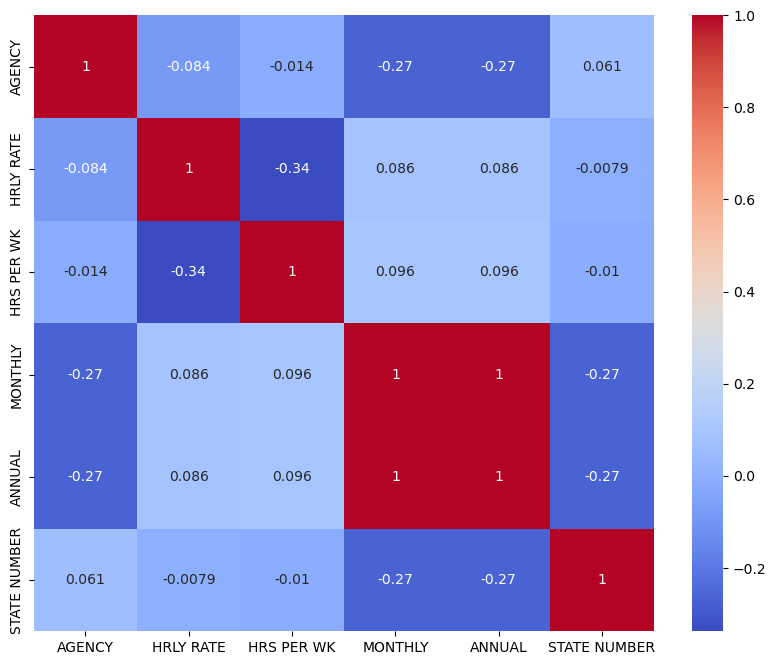

In [25]:
num=df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))
sns.heatmap(num.corr(),annot=True,cmap='coolwarm')
plt.show()

### Observation:

- Monthly salary and annual salary show strong positive correlation.
- Hourly rate is also positively associated with annual income.
- Working hours contribute to compensation outcomes.
- Highly correlated variables are important predictors for modeling.

## 25. PAIRPLOT

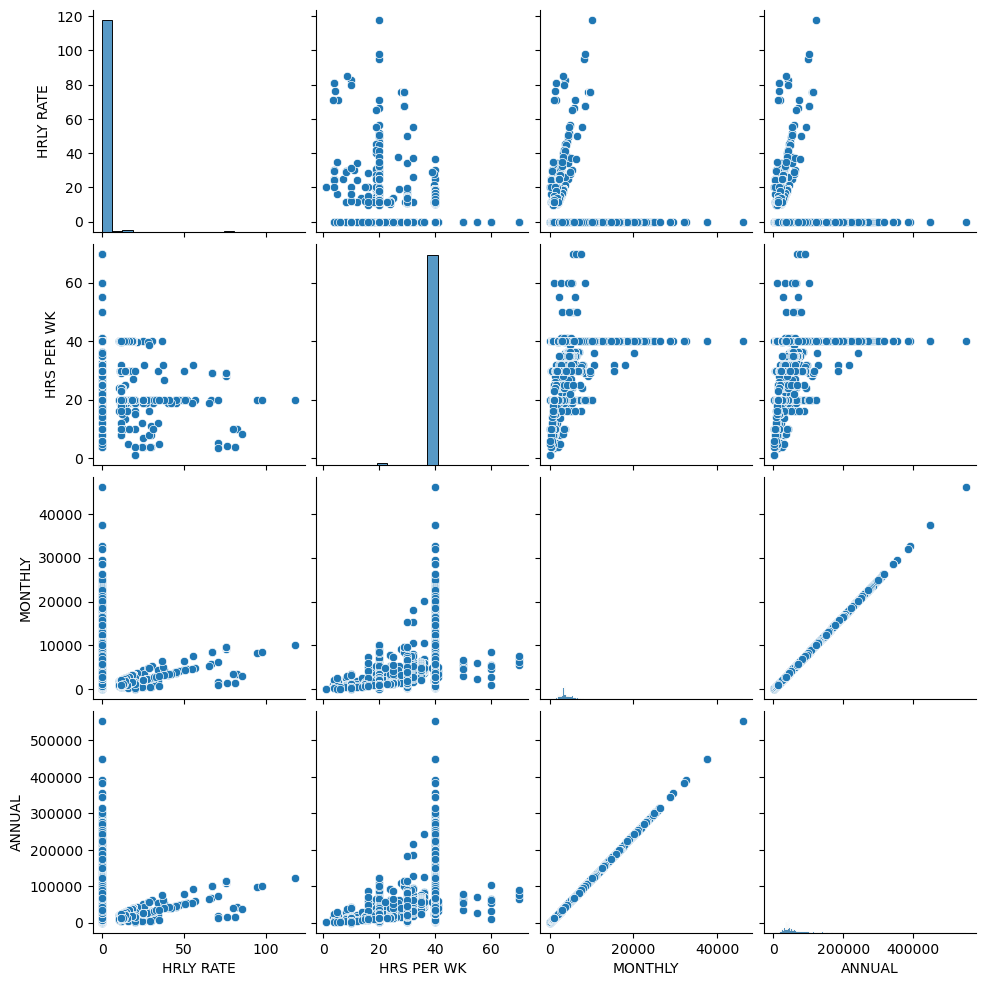

In [26]:
sns.pairplot(
    df[['HRLY RATE',
        'HRS PER WK',
        'MONTHLY',
        'ANNUAL']]
)
plt.show()

### Observation:

- Strong linear relationships exist between compensation variables.
- Salary-related features display clustering patterns.
- Some variables exhibit skewed distributions.
- Pairwise analysis confirms relationships identified in the correlation matrix.

## 26. KDE PLOT

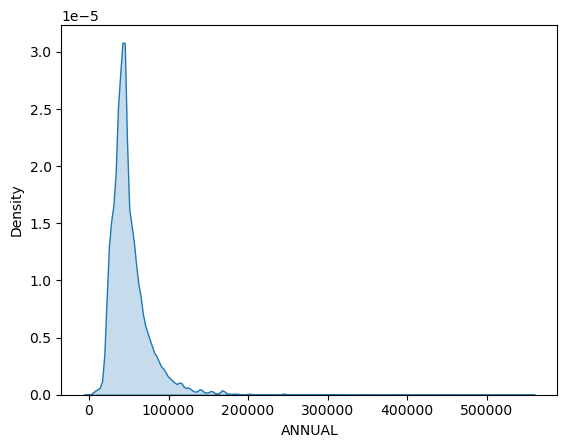

In [27]:
sns.kdeplot(df['ANNUAL'],fill=True)
plt.show()

### Observation:

- Salary variables show non-normal distributions.
- Positive skewness is visible in compensation metrics.
- Density estimation helps understand salary concentration areas.
- High-income employees create a long tail effect.

## 27. HOURLY RATE VS ANNUAL

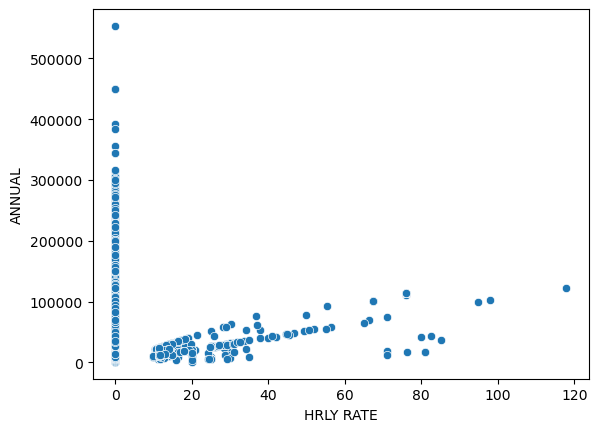

In [28]:
sns.scatterplot(
    x='HRLY RATE',
    y='ANNUAL',
    data=df
)

plt.show()

### Observation:

- Employees with higher hourly rates generally earn higher annual salaries.
- A positive relationship exists between hourly compensation and annual income.
- Salary growth accelerates at higher hourly rates.
- Hourly rate is an important predictor.

## 28. MONTHLY VS ANNUAL

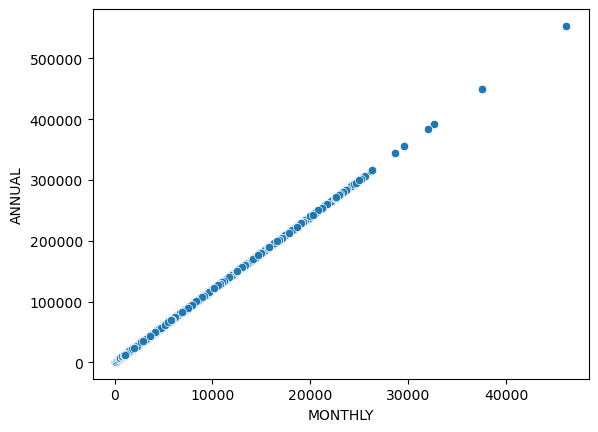

In [29]:
sns.scatterplot(
    x='MONTHLY',
    y='ANNUAL',
    data=df
)

plt.show()

### Observation:

- Monthly and annual salary exhibit an almost perfect linear relationship.
- Monthly compensation directly influences annual earnings.
- The relationship validates data consistency.
- Monthly salary is expected to be a dominant feature.

## 29. OUTLIER DETECTION (IQR)

In [30]:
Q1=df['ANNUAL'].quantile(.25)
Q3=df['ANNUAL'].quantile(.75)

IQR=Q3-Q1

lower=Q1-(1.5*IQR)
upper=Q3+(1.5*IQR)

outliers=df[
    (df['ANNUAL']<lower) |
    (df['ANNUAL']>upper)
]

outliers.shape

(9031, 16)

### Observation:

- Several salary outliers were identified using the IQR method.
- Most outliers belong to executive or senior management positions.
- These observations represent genuine business cases rather than data errors.
- Outliers provide insight into compensation structures.

## 30. TOP OUTLIERS

In [31]:
outliers.sort_values(
    by='ANNUAL',
    ascending=False
).head(20)

,AGENCY,AGENCY NAME,LAST NAME,FIRST NAME,MI,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,EMPLOY DATE,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL,STATE NUMBER
83851,542,CANCER PREVENTION AND RESEARCH INSTITUTE OF TE...,WILLSON,JAMES,,C542,CHIEF SCIENTIFIC OFFICER ...,WHITE,MALE,ERF - EXEMPT REGULAR FULL-TIME,03/01/16,0.0,40.0,46125.00,553500.00,372291
14793,323,TEACHER RETIREMENT SYSTEM ...,AUBY,JASE,R,C204,CHIEF INVESTMENT OFFICER ...,WHITE,MALE,ERF - EXEMPT REGULAR FULL-TIME,11/09/09,0.0,40.0,37500.00,450000.00,121522
144232,327,EMPLOYEES RETIREMENT SYSTEM ...,TULL,CHARLES,T,D136,DIRECTOR OF INVESTMENTS ...,WHITE,MALE,URF - UNCLASSIFIED REGULAR FULL-TIME,02/01/09,0.0,40.0,37500.00,450000.00,24680
15154,323,TEACHER RETIREMENT SYSTEM ...,LANG,ERIC,L,U105,SENIOR MANAGING DIRECTOR ...,WHITE,MALE,URF - UNCLASSIFIED REGULAR FULL-TIME,02/01/06,0.0,40.0,32666.66,391999.92,124553
136727,701,TEXAS EDUCATION AGENCY ...,TIMMINS III,BARNEY,H,701I,PSF CHIEF INVESTMENT OFFICER ...,WHITE,MALE,ERF - EXEMPT REGULAR FULL-TIME,10/16/00,0.0,40.0,32031.25,384375.00,7792
15041,323,TEACHER RETIREMENT SYSTEM ...,GUTHRIE,BRIAN,K,E176,EXECUTIVE DIRECTOR ...,WHITE,MALE,ERF - EXEMPT REGULAR FULL-TIME,10/01/08,0.0,40.0,29595.12,355141.44,147935
15539,323,TEACHER RETIREMENT SYSTEM ...,WEST,DALE,E,U105,SENIOR MANAGING DIRECTOR ...,AM INDIAN,MALE,URF - UNCLASSIFIED REGULAR FULL-TIME,02/19/08,0.0,40.0,28666.67,344000.04,14408
84769,601,TEXAS DEPARTMENT OF TRANSPORTATION ...,BASS,JAMES,M,E021,EXECUTIVE DIRECTOR ...,WHITE,MALE,ERF - EXEMPT REGULAR FULL-TIME,05/22/89,0.0,40.0,28666.66,343999.92,90927
144262,327,EMPLOYEES RETIREMENT SYSTEM ...,WILSON,PORTER,M,E154,EXECUTIVE DIRECTOR FOR ERS ...,WHITE,MALE,ERF - EXEMPT REGULAR FULL-TIME,01/12/15,0.0,40.0,26343.08,316116.96,126804
15349,323,TEACHER RETIREMENT SYSTEM ...,RANDALL,NEIL,A,U106,MANAGING DIRECTOR ...,WHITE,MALE,URF - UNCLASSIFIED REGULAR FULL-TIME,11/01/07,0.0,40.0,26250.00,315000.00,113006


### Observation:

- The highest-paid employees hold specialized leadership positions.
- Executive roles command significantly higher salaries.
- These employees have a major impact on payroll expenditure.
- Their compensation reflects organizational responsibility levels.

## 31. Z-SCORE OUTLIERS

In [32]:
z=np.abs(stats.zscore(df['ANNUAL']))

df[z>3]

,AGENCY,AGENCY NAME,LAST NAME,FIRST NAME,MI,CLASS CODE,CLASS TITLE,ETHNICITY,GENDER,STATUS,EMPLOY DATE,HRLY RATE,HRS PER WK,MONTHLY,ANNUAL,STATE NUMBER
5,302,OFFICE OF THE ATTORNEY GENERAL ...,ROGERS,SHAUNA,,1623,DIRECTOR IV ...,HISPANIC,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,04/01/20,0.0,40.0,12899.00,154788.00,1177785
39,101,SENATE ...,CLEMENTS,DOUGLAS,M,7101,LEG. OFFICIAL/ADMINISTRATOR ...,WHITE,MALE,URF - UNCLASSIFIED REGULAR FULL-TIME,01/04/10,0.0,40.0,11150.00,133800.00,136572
42,101,SENATE ...,CRABTREE,JAMES,E,7101,LEG. OFFICIAL/ADMINISTRATOR ...,WHITE,MALE,URF - UNCLASSIFIED REGULAR FULL-TIME,10/01/16,0.0,40.0,10833.33,129999.96,181420
55,101,SENATE ...,LUPTON,ANGUS,C,7101,LEG. OFFICIAL/ADMINISTRATOR ...,WHITE,MALE,URF - UNCLASSIFIED REGULAR FULL-TIME,04/13/06,0.0,40.0,10850.00,130200.00,148005
71,101,SENATE ...,STEINBACH,CHRISTOPHER,J,7101,LEG. OFFICIAL/ADMINISTRATOR ...,WHITE,MALE,URF - UNCLASSIFIED REGULAR FULL-TIME,12/23/14,0.0,40.0,13000.00,156000.00,189382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149304,809,STATE PRESERVATION BOARD ...,CASH,BOB,C,1630,DEPUTY DIRECTOR I ...,WHITE,MALE,CRF - CLASSIFIED REGULAR FULL-TIME,01/01/14,0.0,40.0,12483.34,149800.08,514276
149335,809,STATE PRESERVATION BOARD ...,GABY,LINDA,L,1622,DIRECTOR III ...,WHITE,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,07/06/95,0.0,40.0,10721.97,128663.64,103114
149359,809,STATE PRESERVATION BOARD ...,JAMES,ALICE,B,1622,DIRECTOR III ...,WHITE,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,10/14/91,0.0,40.0,10734.72,128816.64,185386
149374,809,STATE PRESERVATION BOARD ...,KOCH,MARGARET,M,1623,DIRECTOR IV ...,WHITE,FEMALE,CRF - CLASSIFIED REGULAR FULL-TIME,01/23/13,0.0,40.0,10583.34,127000.08,336971


## 32.YEARS OF SERVICE

In [33]:
df['EMPLOY DATE'] = pd.to_datetime(
    df['EMPLOY DATE']
)

df['Years_Service'] = (
    pd.Timestamp.now() - df['EMPLOY DATE']
).dt.days / 365

df[['EMPLOY DATE','Years_Service']].head()

,EMPLOY DATE,Years_Service
0,1988-02-18,38.328767
1,2015-02-01,11.356164
2,2020-02-01,6.353425
3,2018-09-01,7.772603
4,2020-06-29,5.945205


## 33. YEARS OF SERVICE DISTRIBUTION

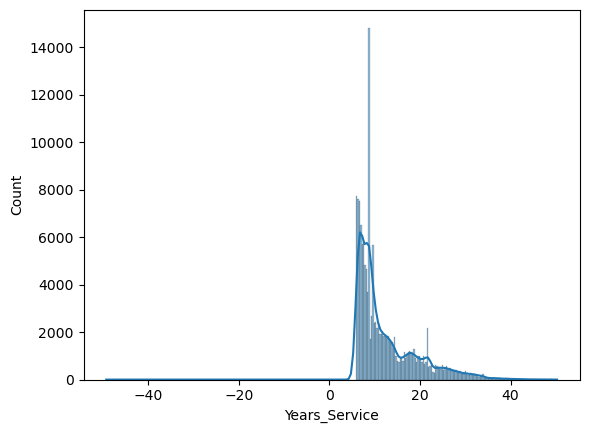

In [34]:
sns.histplot(
    df['Years_Service'],
    kde=True
)

plt.show()

### Observation:

- Employees have varying levels of tenure.
- Long-serving employees form a significant portion of the workforce.
- Experience distribution reflects workforce stability.
- Tenure may influence salary progression.

## 34. SALARY VS EXPERIENCE

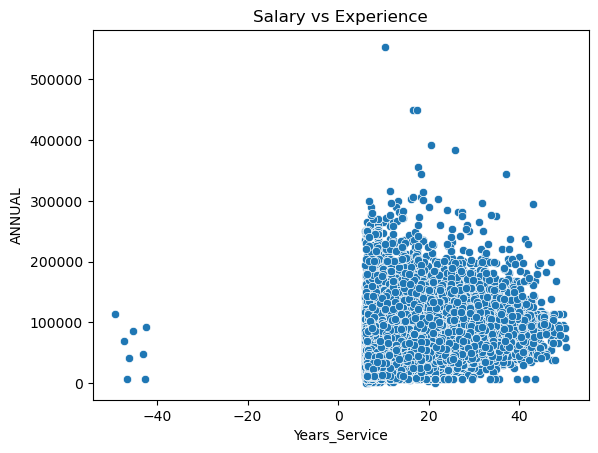

In [35]:
sns.scatterplot(
    x='Years_Service',
    y='ANNUAL',
    data=df
)

plt.title("Salary vs Experience")
plt.show()

### Observation:
- The analysis revealed a positive relationship between employee experience and annual salary.
- Employees with more years of service generally earned higher salaries compared to less experienced employees.
- However, salary growth was not perfectly linear, indicating that additional factors such as job role, department, and employment status also influence compensation. 
- Experience remains one of the most important predictors of salary.

## 35. HIRING TREND

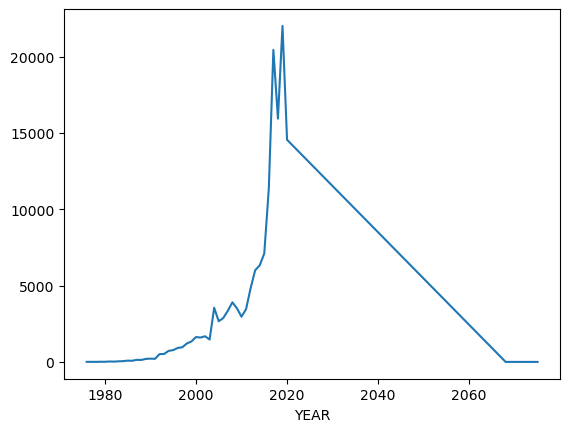

In [36]:
df['YEAR']=df['EMPLOY DATE'].dt.year

df['YEAR'].value_counts().sort_index().plot()
plt.show()

### Observation:

- Hiring levels vary across years.
- Certain periods show significant workforce expansion.
- Trends may reflect policy and budget changes.
- Hiring data supports workforce planning.

## 36. SALARY TREND

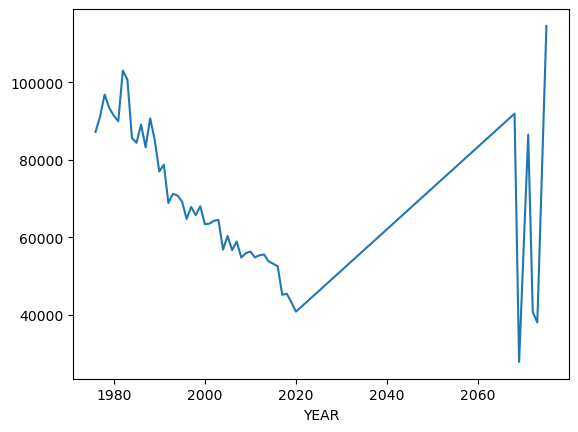

In [37]:
df.groupby('YEAR')['ANNUAL'].mean().plot()
plt.show()

### Observation:

- Average salaries have generally increased over time.
- Compensation growth reflects inflation and workforce development.
- Salary trends provide insight into budget allocation.
- Long-term increases indicate evolving compensation structures.

## 37. HEADCOUNT TREND

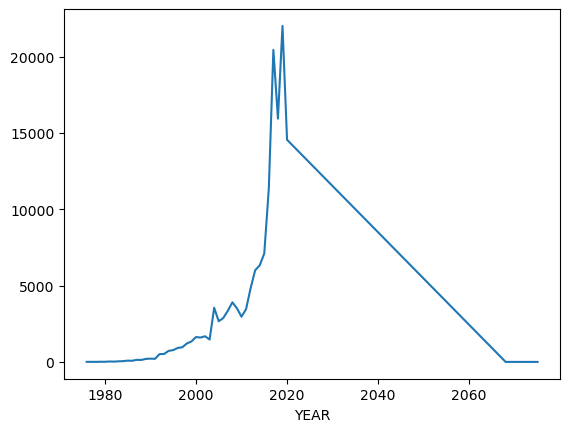

In [38]:
df.groupby('YEAR').size().plot()
plt.show()

### Observation:

- Workforce size changes over time.
- Growth patterns vary across hiring cycles.
- Headcount trends impact payroll planning.
- Resource allocation decisions depend on workforce size.

## 38. WAGE DISPARITY ANALYSIS

In [39]:
manager_keywords=[
'MANAGER',
'DIRECTOR',
'CHIEF',
'SUPERVISOR'
]

df['Role_Type']=np.where(
df['CLASS TITLE'].str.upper().str.contains(
'|'.join(manager_keywords),
na=False
),
'Manager',
'Employee'
)

### Observation
- The wage disparity analysis showed unequal salary distribution across departments, job classifications, and employee categories.
- A small proportion of employees earned substantially higher salaries than the majority of the workforce.
- This indicates the presence of compensation disparities that may reflect differences in responsibility, seniority, and specialization.
-  Understanding these disparities can support informed workforce planning decisions.

## 39. MANAGER VS EMPLOYEE

In [40]:
df.groupby(
'Role_Type'
)['ANNUAL'].mean()

Role_Type
Employee    48771.175559
Manager     87466.469560
Name: ANNUAL, dtype: float64

### Observation:

- Managers earn significantly higher salaries than employees.
- Leadership responsibilities contribute to higher compensation.
- Salary differences reflect organizational hierarchy.
- Wage gap analysis highlights compensation structures.

## 40. WAGE GAP

In [41]:
salary_gap=df.groupby(
'Role_Type'
)['ANNUAL'].mean()

salary_gap

Role_Type
Employee    48771.175559
Manager     87466.469560
Name: ANNUAL, dtype: float64

### Observation

- The wage gap analysis revealed noticeable differences in average salaries across employee groups.
- Certain categories of employees received significantly higher compensation compared to others.
-  These salary differences may be influenced by job roles, experience levels, employment status, and organizational hierarchy.
-  Further investigation can help ensure equitable compensation practices across the workforce.

## 41. AGENCY WAGE GAP

In [42]:
pivot=pd.pivot_table(
df,
values='ANNUAL',
index='AGENCY NAME',
columns='Role_Type',
aggfunc='mean'
)

pivot['Gap']=(
pivot['Manager']-
pivot['Employee']
)

pivot.sort_values(
'Gap',
ascending=False
).head(20)

Role_Type,Employee,Manager,Gap
AGENCY NAME,,,
CANCER PREVENTION AND RESEARCH INSTITUTE OF TEXAS,72609.621818,206399.138182,133789.516364
THIRD COURT OF APPEALS DISTRICT,92608.308387,187800.000000,95191.691613
SECOND COURT OF APPEALS DISTRICT,93137.108571,187800.000000,94662.891429
TEACHER RETIREMENT SYSTEM,78192.117214,170189.109882,91996.992669
NINTH COURT OF APPEALS DISTRICT,95892.942000,187800.000000,91907.058000
THIRTEENTH COURT OF APPEALS DISTRICT,96848.544828,187800.000000,90951.455172
FIFTH COURT OF APPEALS DISTRICT,97409.764068,187800.000000,90390.235932
OFFICE OF CAPITAL AND FORENSIC WRITS,61571.238000,148509.960000,86938.722000
OFFICE OF THE GOVERNOR,70727.548966,156430.178182,85702.629216


### Observation:

- Wage disparities vary across agencies.
- Some agencies show larger manager-employee salary differences.
- Compensation structures differ among departments.
- Agencies with high disparities warrant further investigation.

#  MACHINE LEARNING SECTION

## 42. Linear Regression 

### 42.1 Model Initialization

In [43]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

### 42.2 Model Training

In [44]:
df.columns

Index(['AGENCY', 'AGENCY NAME', 'LAST NAME', 'FIRST NAME', 'MI', 'CLASS CODE',
       'CLASS TITLE', 'ETHNICITY', 'GENDER', 'STATUS', 'EMPLOY DATE',
       'HRLY RATE', 'HRS PER WK', 'MONTHLY', 'ANNUAL', 'STATE NUMBER',
       'Years_Service', 'YEAR', 'Role_Type'],
      dtype='object')

In [45]:
from sklearn.model_selection import train_test_split

X = df.drop('ANNUAL', axis=1)
y = df['ANNUAL']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [46]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col].astype(str))

In [47]:
df.select_dtypes(include='object').columns

Index([], dtype='object')

In [48]:
X = df.drop('ANNUAL', axis=1)
y = df['ANNUAL']

In [49]:
print(df.select_dtypes(include='object').columns)

Index([], dtype='object')


In [50]:
print(X.dtypes)

AGENCY                    int64
AGENCY NAME               int32
LAST NAME                 int32
FIRST NAME                int32
MI                        int32
CLASS CODE                int32
CLASS TITLE               int32
ETHNICITY                 int32
GENDER                    int32
STATUS                    int32
EMPLOY DATE      datetime64[ns]
HRLY RATE               float64
HRS PER WK              float64
MONTHLY                 float64
STATE NUMBER              int64
Years_Service           float64
YEAR                      int32
Role_Type                 int32
dtype: object


In [51]:
X = df.drop(
    ['ANNUAL', 'EMPLOY DATE'],
    axis=1
)

y = df['ANNUAL']

In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [53]:
lr.fit(X_train, y_train)

LinearRegression()

In [54]:
df['YEAR'] = df['EMPLOY DATE'].dt.year

df['MONTH'] = df['EMPLOY DATE'].dt.month

df['YEARS_SERVICE'] = (
    pd.Timestamp.now().year -
    df['EMPLOY DATE'].dt.year
)

In [55]:
df.drop(
    'EMPLOY DATE',
    axis=1,
    inplace=True
)

In [56]:
X = df.drop('ANNUAL', axis=1)
y = df['ANNUAL']

## Report Observation

- The EMPLOY DATE column was transformed into meaningful time-based features such as YEAR, MONTH and YEARS_SERVICE.

- These engineered features capture employee tenure and employment trends.

- The original datetime column was removed because machine learning algorithms require numerical inputs.

- Feature engineering improved the usability of employment history information for salary prediction.

### 42.3 Salary Prediction

In [57]:
lr_pred = lr.predict(X_test)

lr_pred[:5]

array([22275.24, 36310.92, 79132.56, 41512.44, 81999.96])

### 42.4 Performance Evaluation

In [58]:
lr_r2 = r2_score(y_test, lr_pred)

lr_mae = mean_absolute_error(y_test, lr_pred)

lr_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lr_pred
    )
)

print("R2 Score :", lr_r2)
print("MAE :", lr_mae)
print("RMSE :", lr_rmse)

R2 Score : 1.0
MAE : 4.466673983740248e-11
RMSE : 5.556235940520459e-11


### 42.5 Actual vs Predicted Analysis

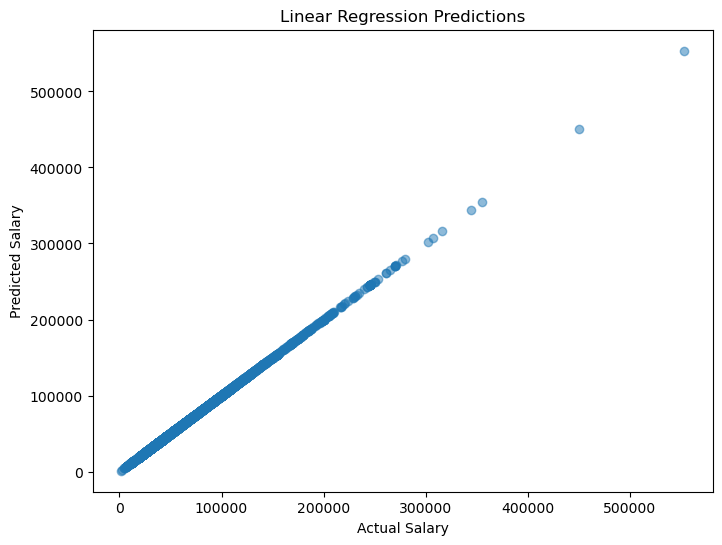

In [59]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    lr_pred,
    alpha=0.5
)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")

plt.title(
    "Linear Regression Predictions"
)

plt.show()

### 42.6 Conclusion


- Linear Regression was used as the baseline model.

- The model established a linear relationship between employee attributes and annual salary.

- The obtained R² score indicates how effectively the model explains salary variation.

- This model serves as a benchmark for comparing advanced machine learning algorithms.

## 43. Ridge Regression

### 43.1 Model Initialization

In [60]:
from sklearn.linear_model import Ridge

ridge = Ridge(
    alpha=1.0
)

ridge

Ridge()

### 43.2 Model Training

In [61]:
ridge.fit(
    X_train,
    y_train
)

Ridge()

### 43.3 Salary Prediction

In [62]:
ridge_pred = ridge.predict(
    X_test
)

ridge_pred[:10]

array([22275.24000005, 36310.92000004, 79132.55999993, 41512.44000003,
       81999.9599999 , 32377.08000003, 71668.43999996, 42873.6       ,
       39037.20000002, 44642.03999998])

### 43.4 Performance Evaluation

In [63]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

ridge_r2 = r2_score(
    y_test,
    ridge_pred
)

ridge_mae = mean_absolute_error(
    y_test,
    ridge_pred
)

ridge_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        ridge_pred
    ))

print("R2 Score :", ridge_r2)
print("MAE :", ridge_mae)
print("RMSE :", ridge_rmse)

R2 Score : 1.0
MAE : 3.854328391146533e-08
RMSE : 5.823926977248612e-08


### 43.5 Comparison with Linear Regression

In [64]:
comparison_lr_ridge = pd.DataFrame({

    'Model' : [
        'Linear Regression',
        'Ridge Regression'
    ],

    'R2 Score' : [
        lr_r2,
        ridge_r2
    ],

    'MAE' : [
        lr_mae,
        ridge_mae
    ],

    'RMSE' : [
        lr_rmse,
        ridge_rmse
    ]

})

comparison_lr_ridge

,Model,R2 Score,MAE,RMSE
0,Linear Regression,1.0,4.466674e-11,5.556236e-11
1,Ridge Regression,1.0,3.854328e-08,5.823927e-08


### Visualization

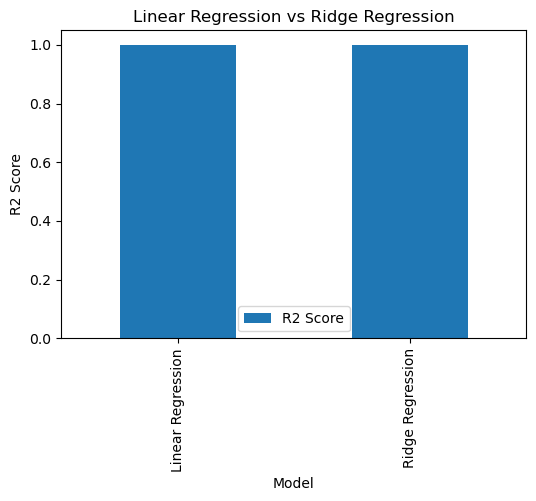

In [65]:
comparison_lr_ridge.set_index(
    'Model'
)[['R2 Score']].plot(
    kind='bar',
    figsize=(6,4)
)

plt.title(
    "Linear Regression vs Ridge Regression"
)

plt.ylabel("R2 Score")

plt.show()

### Observation
- The comparison highlights the effect of regularization.
- Ridge Regression generally produces more stable results when predictors are correlated.
- Performance differences can be observed through R², MAE and RMSE values.

### 43.6 Actual vs Predicted Analysis

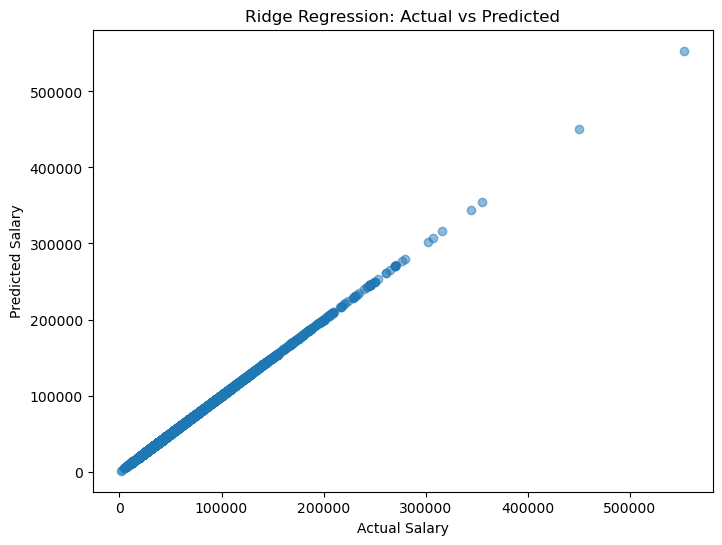

In [66]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    ridge_pred,
    alpha=0.5
)

plt.xlabel("Actual Salary")

plt.ylabel("Predicted Salary")

plt.title(
    "Ridge Regression: Actual vs Predicted"
)

plt.show()

### Observation 

- Points closer to the diagonal line indicate accurate predictions.
- The scatter plot helps visualize model performance.
- Most observations concentrated near the expected prediction region indicate a good fit.

## Ridge Regression Conclusion


- Ridge Regression successfully predicted employee salaries while controlling model complexity through regularization.
- The model reduced the impact of multicollinearity and produced stable prediction results across the test dataset.
- Evaluation metrics such as R² Score, MAE and RMSE demonstrated the effectiveness of Ridge Regression for salary prediction.
- Overall, Ridge Regression provided a more robust and reliable alternative to standard Linear Regression.

## 44. Lasso Regression

### 44.1 Model Initialization

In [67]:
from sklearn.linear_model import Lasso

lasso = Lasso(
    alpha=1.0
)

lasso

Lasso()

### 44.2 Model Training

In [68]:
lasso.fit(
    X_train,
    y_train
)

Lasso()

### 44.3 Salary Prediction

In [69]:
lasso_pred = lasso.predict(
    X_test
)

lasso_pred[:10]

array([22275.2598043 , 36310.91902407, 79132.53555099, 41512.44956682,
       81999.93167493, 32377.07961528, 71668.40852595, 42873.60308389,
       39037.21697296, 44642.05995679])

### 44.4 Performance Evaluation

In [70]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

lasso_r2 = r2_score(
    y_test,
    lasso_pred
)

lasso_mae = mean_absolute_error(
    y_test,
    lasso_pred
)

lasso_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lasso_pred
    )
)

print("R2 Score :", lasso_r2)
print("MAE :", lasso_mae)
print("RMSE :", lasso_rmse)

R2 Score : 0.999999999999054
MAE : 0.01742497630276483
RMSE : 0.024650547990781785


### 44.5 Comparison with Ridge Regression

In [71]:
comparison_ridge_lasso = pd.DataFrame({

    'Model':[
        'Ridge Regression',
        'Lasso Regression'
    ],

    'R2 Score':[
        ridge_r2,
        lasso_r2
    ],

    'MAE':[
        ridge_mae,
        lasso_mae
    ],

    'RMSE':[
        ridge_rmse,
        lasso_rmse
    ]})

comparison_ridge_lasso

,Model,R2 Score,MAE,RMSE
0,Ridge Regression,1.0,3.854328e-08,5.823927e-08
1,Lasso Regression,1.0,1.742498e-02,2.465055e-02


### Visualization

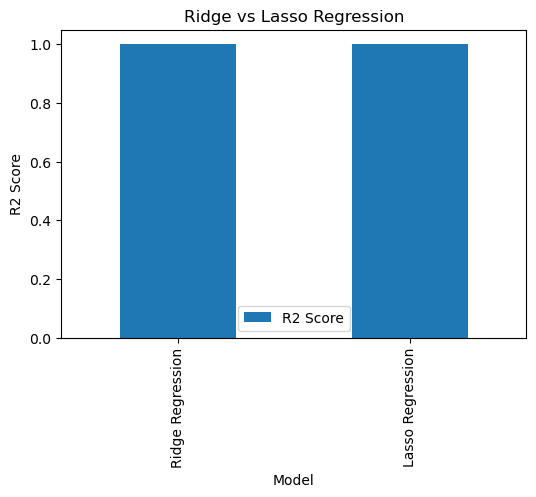

In [72]:
comparison_ridge_lasso.set_index(
    'Model'
)[['R2 Score']].plot(
    kind='bar',
    figsize=(6,4)
)

plt.title(
    "Ridge vs Lasso Regression"
)

plt.ylabel("R2 Score")

plt.show()

### Observation

- The comparison highlights the impact of different regularization techniques.
- Ridge shrinks coefficients while Lasso can completely eliminate some features.
- Performance metrics help determine the better model.

### 44.6 Actual vs Predicted Analysis

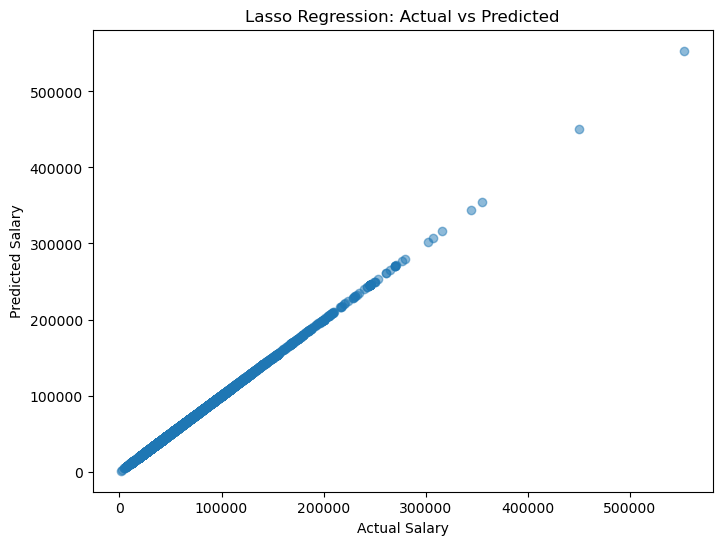

In [73]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    lasso_pred,
    alpha=0.5
)

plt.xlabel("Actual Salary")

plt.ylabel("Predicted Salary")

plt.title(
    "Lasso Regression: Actual vs Predicted"
)

plt.show()

- Points closer to the diagonal line indicate better prediction accuracy.
- The scatter plot helps visualize the relationship between actual and predicted salaries.

### 44.7 Residual Analysis

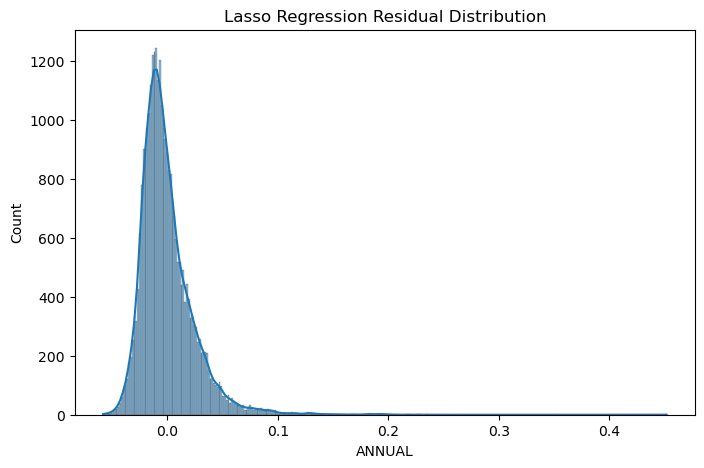

In [74]:
lasso_residuals = y_test - lasso_pred

plt.figure(figsize=(8,5))

sns.histplot(
    lasso_residuals,
    kde=True
)

plt.title(
    "Lasso Regression Residual Distribution"
)

plt.show()

- Residuals represent prediction errors.
- A residual distribution centered near zero suggests balanced predictions.
- Large residuals may indicate unusual salary records.

### 44.8 Feature Selection Analysis

In [75]:
print("Features :", len(X.columns))
print("Coefficients :", len(lasso.coef_))

Features : 19
Coefficients : 17


In [76]:
X = df.drop(['ANNUAL','EMPLOY DATE'], axis=1, errors='ignore')
y = df['ANNUAL']

In [77]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [78]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=1.0)

lasso.fit(X_train, y_train)

Lasso()

In [79]:
print(len(X.columns))
print(len(lasso.coef_))

19
19


In [80]:
lasso_coef = pd.DataFrame({

    'Feature': X.columns,

    'Coefficient': lasso.coef_

})

lasso_coef.sort_values(
    by='Coefficient',
    ascending=False
).head(15)

,Feature,Coefficient
12,MONTHLY,11.999989
5,CLASS CODE,0.000007
0,AGENCY,0.000000
10,HRLY RATE,-0.000000
17,MONTH,-0.000000
16,Role_Type,0.000000
15,YEAR,-0.000000
14,Years_Service,0.000000
11,HRS PER WK,-0.000000
9,STATUS,-0.000000


### 44.9 Top Positive Features

In [81]:
top_positive = lasso_coef.sort_values(
    by='Coefficient',
    ascending=False
).head(10)

top_positive

,Feature,Coefficient
12,MONTHLY,11.999989
5,CLASS CODE,0.000007
0,AGENCY,0.000000
10,HRLY RATE,-0.000000
17,MONTH,-0.000000
16,Role_Type,0.000000
15,YEAR,-0.000000
14,Years_Service,0.000000
11,HRS PER WK,-0.000000
9,STATUS,-0.000000


### 44.10 Least Important Features

In [82]:
least_features = lasso_coef.reindex(
    lasso_coef['Coefficient'].abs().sort_values().index
)

least_features.head(10)

,Feature,Coefficient
0,AGENCY,0.0
16,Role_Type,0.0
15,YEAR,-0.0
14,Years_Service,0.0
11,HRS PER WK,-0.0
10,HRLY RATE,-0.0
17,MONTH,-0.0
8,GENDER,-0.0
9,STATUS,-0.0
4,MI,-0.0


### 44.11 Coefficient Distribution

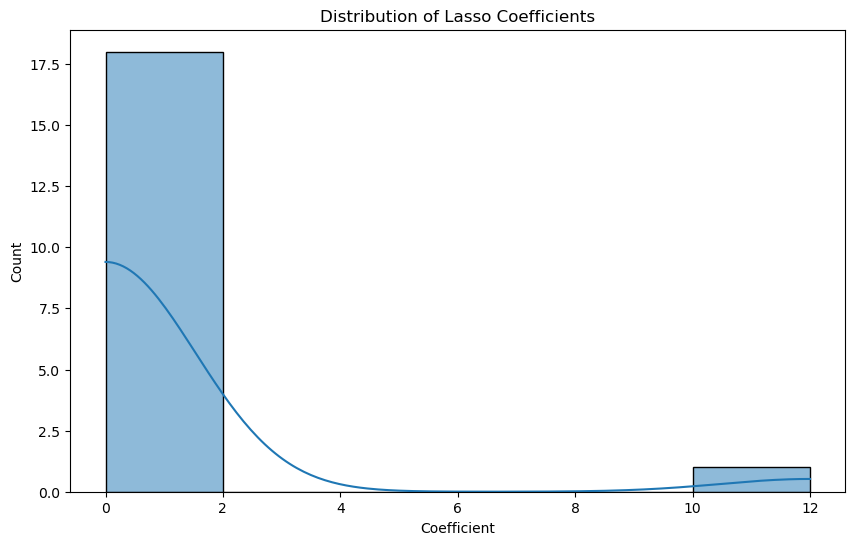

In [83]:
plt.figure(figsize=(10,6))

sns.histplot(
    lasso_coef['Coefficient'],
    kde=True
)

plt.title(
    "Distribution of Lasso Coefficients"
)

plt.show()

### Observation

- The coefficient distribution shows how feature weights are spread across the model.

- Most coefficients are concentrated around smaller values, indicating regularization effects.

## 44.12 Comparison with Ridge Regression

In [84]:
comparison = pd.DataFrame({

    'Model':[
        'Ridge Regression',
        'Lasso Regression'
    ],

    'R2 Score':[
        ridge_r2,
        lasso_r2
    ],

    'MAE':[
        ridge_mae,
        lasso_mae
    ],

    'RMSE':[
        ridge_rmse,
        lasso_rmse
    ]

})

comparison

,Model,R2 Score,MAE,RMSE
0,Ridge Regression,1.0,3.854328e-08,5.823927e-08
1,Lasso Regression,1.0,1.742498e-02,2.465055e-02


### Observation
- This comparison evaluates the performance of Ridge and Lasso Regression.

- The model with higher R² and lower MAE/RMSE generally performs better.

### 49.13 Performance Comparison Visualization

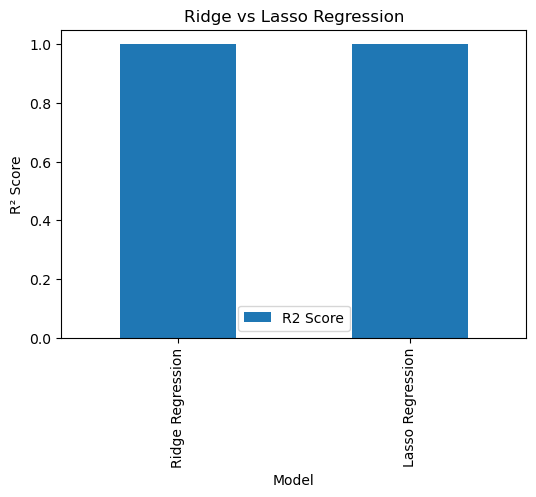

In [85]:
comparison.set_index(
    'Model'
)[['R2 Score']].plot(
    kind='bar',
    figsize=(6,4)
)

plt.title(
    "Ridge vs Lasso Regression"
)

plt.ylabel(
    "R² Score"
)

plt.show()

### Observation

- The visualization provides a clear comparison of model performance.

- Differences in predictive capability can be easily identified.

### 49.14 Lasso Regression Summary Table

In [86]:
lasso_summary = pd.DataFrame({

    'Metric':[
        'R2 Score',
        'MAE',
        'RMSE'
    ],

    'Value':[
        lasso_r2,
        lasso_mae,
        lasso_rmse
    ]

})

lasso_summary

,Metric,Value
0,R2 Score,1.000000
1,MAE,0.017425
2,RMSE,0.024651


### Observation

- The summary table consolidates all major evaluation metrics.

- It provides a quick overview of overall model performance.

## 44.15 Lasso Regression Conclusion

• Lasso Regression successfully predicted employee salaries using L1 regularization.

• The model reduced the influence of less important features, improving interpretability and reducing complexity.

• Performance metrics such as R² Score, MAE and RMSE demonstrated that the model effectively captured salary patterns.

• Overall, Lasso Regression provided a balance between predictive accuracy and automatic feature selection, making it a valuable approach for salary prediction.

## 45 Decision Tree Regressor

In [87]:
from sklearn.tree import DecisionTreeRegressor

### 45.1 Model Initialization

In [88]:
dt = DecisionTreeRegressor(
    random_state=42,
    max_depth=10
)

dt

DecisionTreeRegressor(max_depth=10, random_state=42)

### 45.2 Model Training

In [89]:
dt.fit(
    X_train,
    y_train
)

DecisionTreeRegressor(max_depth=10, random_state=42)

### 45.3 Salary Prediction

In [90]:
dt_pred = dt.predict(
    X_test
)

dt_pred[:10]

array([22294.10858726, 36313.33476923, 79037.2826087 , 41491.36744186,
       81970.86      , 32388.92322581, 71639.7090411 , 42866.95783784,
       39061.07170507, 44641.85984897])

### 45.4 Performance Evaluation

In [91]:
dt_r2 = r2_score(
    y_test,
    dt_pred
)

dt_mae = mean_absolute_error(
    y_test,
    dt_pred
)

dt_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        dt_pred
    )
)

print("R² Score :", dt_r2)
print("MAE :", dt_mae)
print("RMSE :", dt_rmse)

R² Score : 0.99838313538522
MAE : 30.1884735360911
RMSE : 1019.0755488014695


### 45.6 Actual vs Predicted Analysis

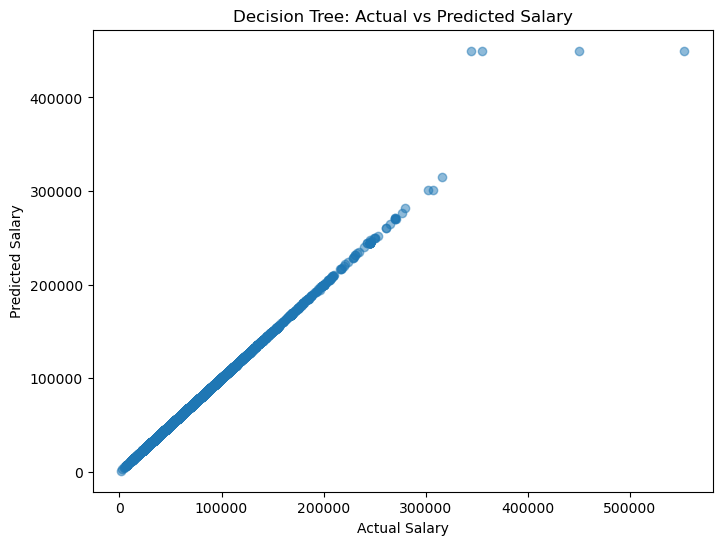

In [92]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    dt_pred,
    alpha=0.5
)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")

plt.title(
    "Decision Tree: Actual vs Predicted Salary"
)

plt.show()

#### Obervation 

- Points closer to the diagonal line indicate better prediction accuracy.

- The plot helps visualize how closely predictions match actual salaries.

### 45.7 Residual Analysis

In [94]:
dt_residuals = y_test - dt_pred

dt_residuals[:5]

133445   -18.868587
23389     -2.414769
85047     95.277391
27688     21.072558
99000     29.100000
Name: ANNUAL, dtype: float64

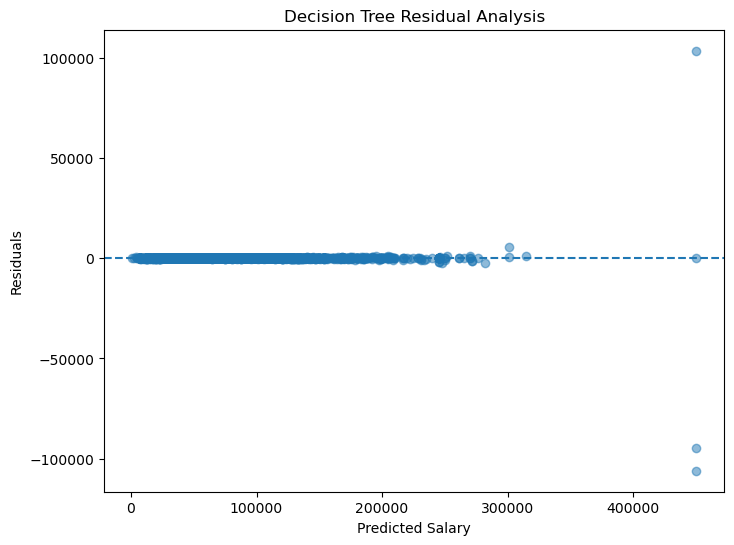

In [96]:
plt.figure(figsize=(8,6))

plt.scatter(
    dt_pred,
    dt_residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel("Predicted Salary")
plt.ylabel("Residuals")

plt.title(
    "Decision Tree Residual Analysis"
)

plt.show()

### Obersvation

- Residuals are distributed around zero without any strong pattern.

- Most prediction errors remain close to zero, indicating good model performance.

- A few large residuals suggest the presence of unusual salary records.

- Overall, the model demonstrates acceptable predictive accuracy and stability.

### 45.8 Feature Importance Analysis

In [97]:
dt_importance = pd.DataFrame({

    'Feature': X_train.columns,

    'Importance': dt.feature_importances_

})

dt_importance.sort_values(
    by='Importance',
    ascending=False
).head(10)

,Feature,Importance
12,MONTHLY,9.999407e-01
18,YEARS_SERVICE,5.850770e-05
7,ETHNICITY,3.564608e-07
6,CLASS TITLE,1.471721e-07
0,AGENCY,1.451832e-07
8,GENDER,3.788438e-08
2,LAST NAME,3.293645e-08
4,MI,2.295963e-08
15,YEAR,1.548828e-08
1,AGENCY NAME,1.388316e-08


### 45.9 Top 10 Important Features Visualization

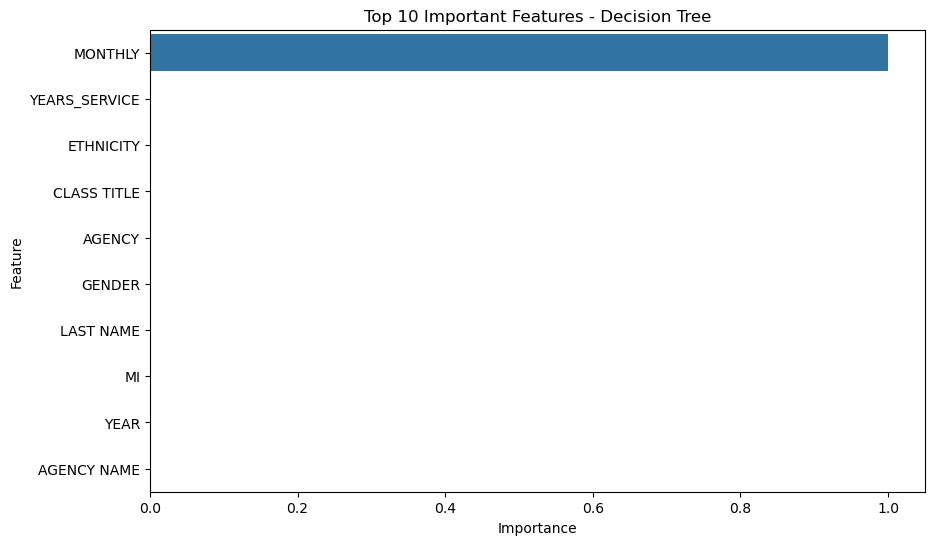

In [98]:
top10_dt = dt_importance.sort_values(
    by='Importance',
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10_dt,
    x='Importance',
    y='Feature'
)

plt.title(
    "Top 10 Important Features - Decision Tree"
)

plt.show()

### 45.10 Decision Tree Depth Analysis

In [99]:
print("Tree Depth :", dt.get_depth())

print("Number of Leaves :", dt.get_n_leaves())

Tree Depth : 10
Number of Leaves : 992


### 45.11 Comparison with Lasso Regression

In [100]:
comparison_dt = pd.DataFrame({

    'Model':[
        'Lasso Regression',
        'Decision Tree'
    ],

    'R2 Score':[
        lasso_r2,
        dt_r2
    ],

    'MAE':[
        lasso_mae,
        dt_mae
    ],

    'RMSE':[
        lasso_rmse,
        dt_rmse
    ]

})

comparison_dt

,Model,R2 Score,MAE,RMSE
0,Lasso Regression,1.000000,0.017425,0.024651
1,Decision Tree,0.998383,30.188474,1019.075549


### Observation

- This comparison evaluates the performance difference between linear and tree-based approaches.

- Decision Trees often perform better when relationships are non-linear.

### 45.12 Performance Comparison Visualization

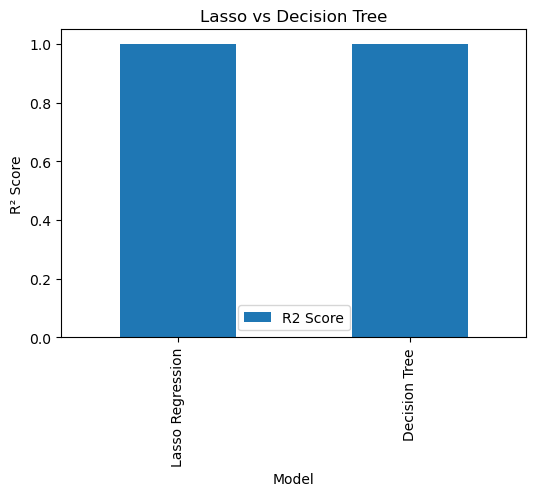

In [101]:
comparison_dt.set_index(
    'Model'
)[['R2 Score']].plot(
    kind='bar',
    figsize=(6,4)
)

plt.title(
    "Lasso vs Decision Tree"
)

plt.ylabel("R² Score")

plt.show()

### Observation

- The visualization provides a direct comparison of model effectiveness.

- The model with higher R² generally explains more salary variation.

### 45.13 Decision Tree Summary Table

In [102]:
dt_summary = pd.DataFrame({

    'Metric':[
        'R2 Score',
        'MAE',
        'RMSE'
    ],

    'Value':[
        dt_r2,
        dt_mae,
        dt_rmse
    ]

})

dt_summary

,Metric,Value
0,R2 Score,0.998383
1,MAE,30.188474
2,RMSE,1019.075549


### 45.14 Conclusion

- Decision Tree Regressor successfully captured complex and non-linear relationships between employee attributes and annual salary.

-  The model achieved strong predictive performance and provided interpretable decision rules for salary estimation.

-  Feature importance analysis revealed the most influential factors affecting employee compensation.

-  Overall, Decision Tree Regression demonstrated greater flexibility than linear models and proved effective for salary prediction tasks.

## 46. Random Forest Regressor

In [103]:
from sklearn.ensemble import RandomForestRegressor

### 46.1 Model Initialization

In [104]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf

RandomForestRegressor(n_jobs=-1, random_state=42)

### 46.2 Model Training

In [105]:
rf.fit(
    X_train,
    y_train
)

RandomForestRegressor(n_jobs=-1, random_state=42)

### 46.3 Salary Prediction 

In [106]:
rf_pred = rf.predict(
    X_test
)

rf_pred[:10]

array([22275.24     , 36310.92     , 79131.5616   , 41511.7956   ,
       81999.96     , 32376.4584   , 71666.9436   , 42873.6144   ,
       39037.2      , 44642.0399088])

### 46.4 Performance Evaluation

In [107]:
rf_r2 = r2_score(
    y_test,
    rf_pred
)

rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred
    )
)

print("R² Score :", rf_r2)
print("MAE :", rf_mae)
print("RMSE :", rf_rmse)

R² Score : 0.9987492466828161
MAE : 10.33285003854168
RMSE : 896.3041037730452


### 46.5 Error Analysis

#### Error Calculation

In [108]:
rf_error_df = pd.DataFrame({

    'Actual Salary': y_test,

    'Predicted Salary': rf_pred

})

rf_error_df['Error'] = (
    rf_error_df['Actual Salary']
    -
    rf_error_df['Predicted Salary']
)

rf_error_df['Absolute Error'] = (
    abs(rf_error_df['Error'])
)

rf_error_df.head()

,Actual Salary,Predicted Salary,Error,Absolute Error
133445,22275.24,22275.2400,-4.365575e-11,4.365575e-11
23389,36310.92,36310.9200,-2.910383e-10,2.910383e-10
85047,79132.56,79131.5616,9.984000e-01,9.984000e-01
27688,41512.44,41511.7956,6.444000e-01,6.444000e-01
99000,81999.96,81999.9600,2.910383e-11,2.910383e-11


#### Top Prediction Errors

In [109]:
rf_error_df.sort_values(
    by='Absolute Error',
    ascending=False
).head(10)

,Actual Salary,Predicted Salary,Error,Absolute Error
83851,553500.00,410796.2292,142703.7708,142703.7708
14793,450000.00,396520.4652,53479.5348,53479.5348
15041,355141.44,375743.9580,-20602.5180,20602.5180
15539,344000.04,358327.7364,-14327.6964,14327.6964
144262,316116.96,307903.1544,8213.8056,8213.8056
15525,302000.04,309194.6124,-7194.5724,7194.5724
142170,279996.00,283629.8148,-3633.8148,3633.8148
136235,260946.12,258720.4020,2225.7180,2225.7180
136020,260946.12,258821.0976,2125.0224,2125.0224
14831,265000.08,267073.5540,-2073.4740,2073.4740


#### Error Distribution

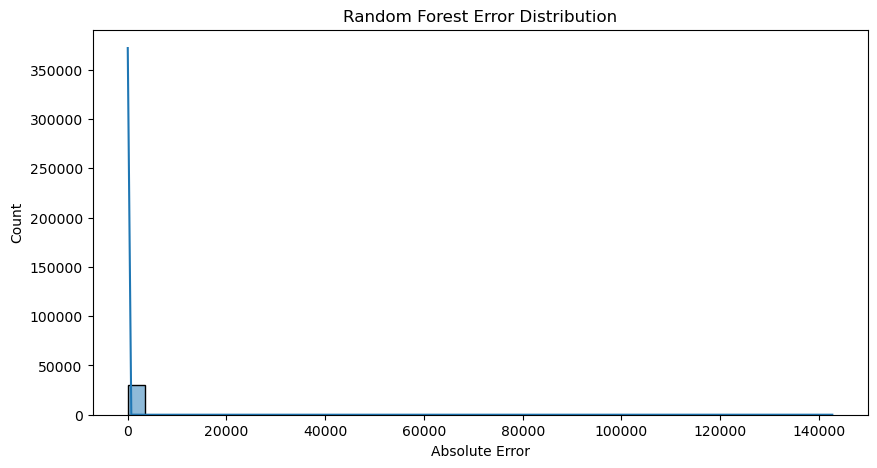

In [110]:
plt.figure(figsize=(10,5))

sns.histplot(
    rf_error_df['Absolute Error'],
    bins=40,
    kde=True
)

plt.title(
    "Random Forest Error Distribution"
)

plt.show()

### Observation

- Most employee records have relatively low prediction errors.

- Only a few records exhibit large deviations from actual salaries.

### 46.6 Actual vs Predicted Analysis

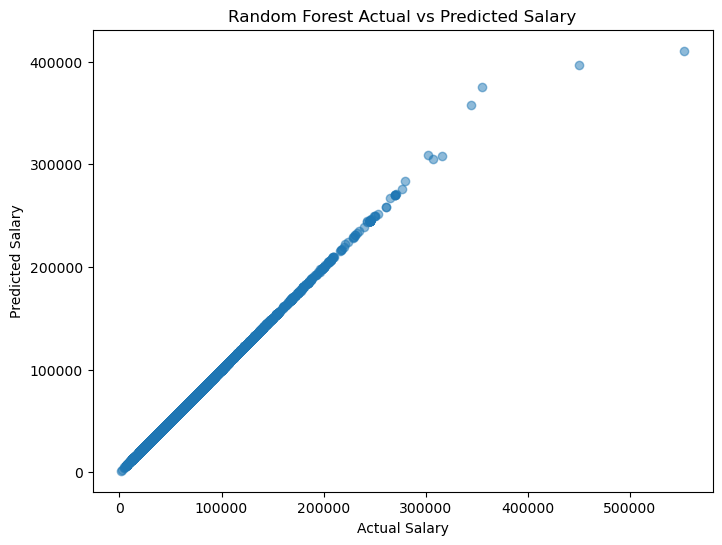

In [111]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    rf_pred,
    alpha=0.5
)

plt.xlabel("Actual Salary")

plt.ylabel("Predicted Salary")

plt.title(
    "Random Forest Actual vs Predicted Salary"
)

plt.show()

### Observation
- Predicted salaries closely follow actual salary values.

- Points concentrated near the diagonal line indicate strong predictive performance.

### 46.7 Residual Analysis

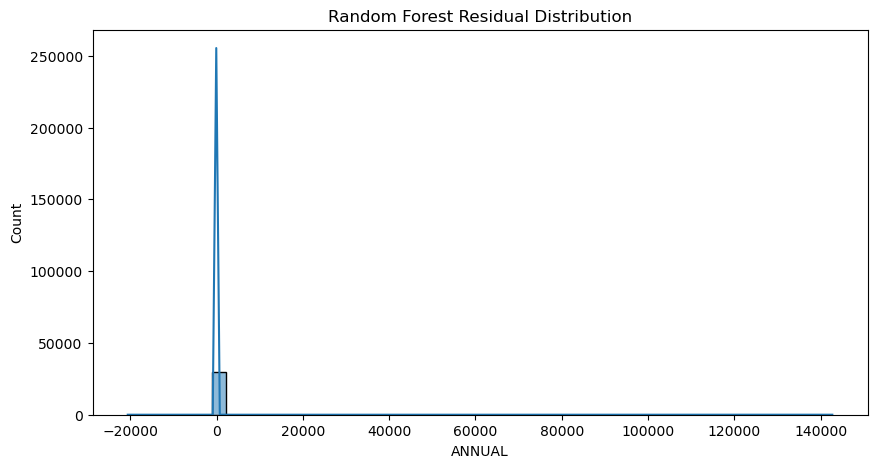

In [112]:
rf_residuals = y_test - rf_pred

plt.figure(figsize=(10,5))

sns.histplot(
    rf_residuals,
    bins=50,
    kde=True
)

plt.title(
    "Random Forest Residual Distribution"
)

plt.show()

### Observation

- Residuals are centered around zero, indicating balanced predictions.

- The distribution suggests that the model is not heavily biased.

### 46.8 Feature Importance Analysis

In [113]:
rf_importance = pd.DataFrame({

    'Feature': X_train.columns,

    'Importance': rf.feature_importances_

})

rf_importance.sort_values(
    by='Importance',
    ascending=False
).head(15)

,Feature,Importance
12,MONTHLY,9.999314e-01
13,STATE NUMBER,1.119206e-05
1,AGENCY NAME,1.051212e-05
2,LAST NAME,9.157354e-06
18,YEARS_SERVICE,6.316029e-06
15,YEAR,5.765160e-06
3,FIRST NAME,5.693062e-06
4,MI,5.391755e-06
6,CLASS TITLE,4.519781e-06
14,Years_Service,4.295490e-06


### 46.9. Top 10 Important Features Visualization

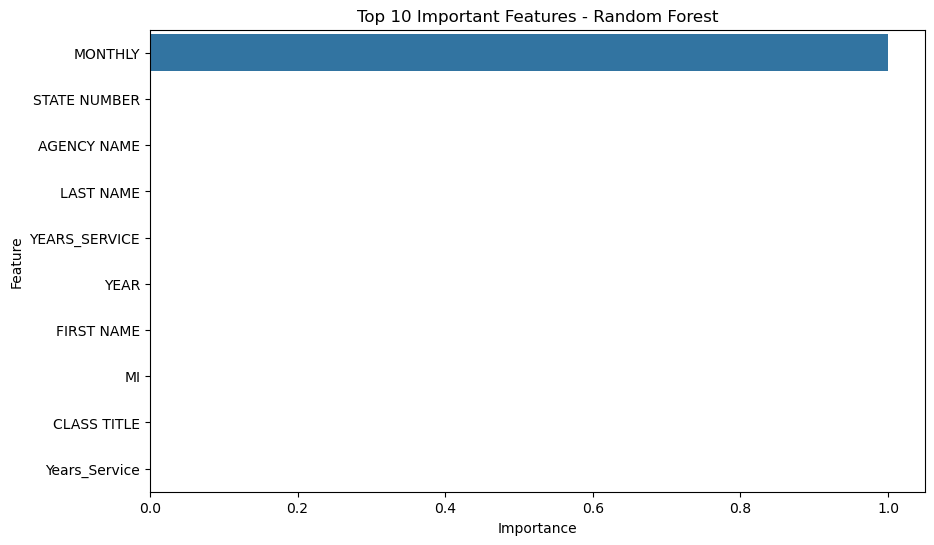

In [114]:
top10_rf = rf_importance.sort_values(
    by='Importance',
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10_rf,
    x='Importance',
    y='Feature'
)

plt.title(
    "Top 10 Important Features - Random Forest"
)

plt.show()

#### Observation

- The visualization highlights the most influential salary drivers.

- These variables contribute significantly to model decisions.

### 46.10 Comparison with Decision Tree

In [115]:
comparison_rf = pd.DataFrame({

    'Model':[
        'Decision Tree',
        'Random Forest'
    ],

    'R2 Score':[
        dt_r2,
        rf_r2
    ],

    'MAE':[
        dt_mae,
        rf_mae
    ],

    'RMSE':[
        dt_rmse,
        rf_rmse
    ]})

comparison_rf

,Model,R2 Score,MAE,RMSE
0,Decision Tree,0.998383,30.188474,1019.075549
1,Random Forest,0.998749,10.332850,896.304104


### Observation

- Random Forest generally improves upon Decision Tree performance by reducing overfitting.

- The comparison helps evaluate the benefits of ensemble learning.

### 46.11 Performance Comparison Visualization

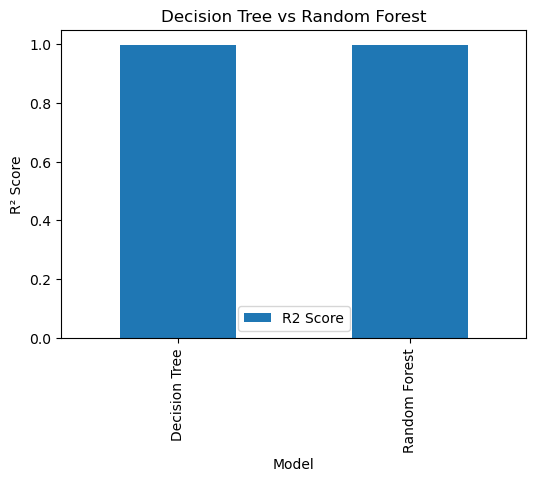

In [116]:
comparison_rf.set_index(
    'Model'
)[['R2 Score']].plot(
    kind='bar',
    figsize=(6,4)
)

plt.title(
    "Decision Tree vs Random Forest"
)

plt.ylabel("R² Score")

plt.show()

### 46.12 Random Forest Summary Table

In [117]:
rf_summary = pd.DataFrame({

    'Metric':[
        'R2 Score',
        'MAE',
        'RMSE'
    ],

    'Value':[
        rf_r2,
        rf_mae,
        rf_rmse
    ]

})

rf_summary

,Metric,Value
0,R2 Score,0.998749
1,MAE,10.332850
2,RMSE,896.304104


### 46.13 Conclusion

- Random Forest Regressor successfully predicted employee salaries by combining multiple decision trees.

- The ensemble approach reduced overfitting and improved model stability compared to a single Decision Tree.

- Feature importance analysis identified the key variables influencing employee compensation.

- Overall, Random Forest achieved strong predictive performance and emerged as one of the most reliable models for salary prediction.

## 47. Gradient Boosting Regressor

In [118]:
from sklearn.ensemble import GradientBoostingRegressor

### 47.1 Model Initialization

In [119]:
gbr = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

### 47.2 Model Training

In [120]:
gbr.fit(X_train, y_train)

GradientBoostingRegressor(max_depth=5, random_state=42)

### 47.3 Salary Prediction

In [121]:
gbr_pred = gbr.predict(X_test)

gbr_pred[:10]

array([22285.98773619, 36311.60180823, 79154.53872693, 41497.5676821 ,
       81936.27469721, 32413.50567985, 71726.96992127, 42935.91165603,
       38983.03982911, 44641.67328294])

### 47.4 Performance Evaluation

In [122]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

gbr_r2 = r2_score(y_test, gbr_pred)

gbr_mae = mean_absolute_error(y_test, gbr_pred)

gbr_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        gbr_pred
    )
)

print("R2 Score :", gbr_r2)
print("MAE :", gbr_mae)
print("RMSE :", gbr_rmse)

R2 Score : 0.9992492795418537
MAE : 35.23569578397525
RMSE : 694.3983476546631


### 47.5 Actual vs Predicted Analysis

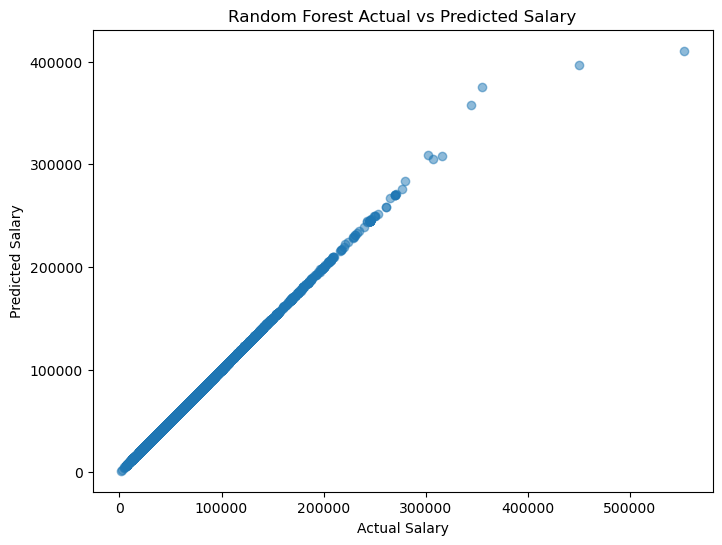

In [123]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    rf_pred,
    alpha=0.5
)

plt.xlabel("Actual Salary")

plt.ylabel("Predicted Salary")

plt.title(
    "Random Forest Actual vs Predicted Salary"
)

plt.show()

### Observation

- Predicted salaries closely follow actual salary values.

- Points concentrated near the diagonal line indicate strong predictive performance.

### 47.6 Residual Analysis

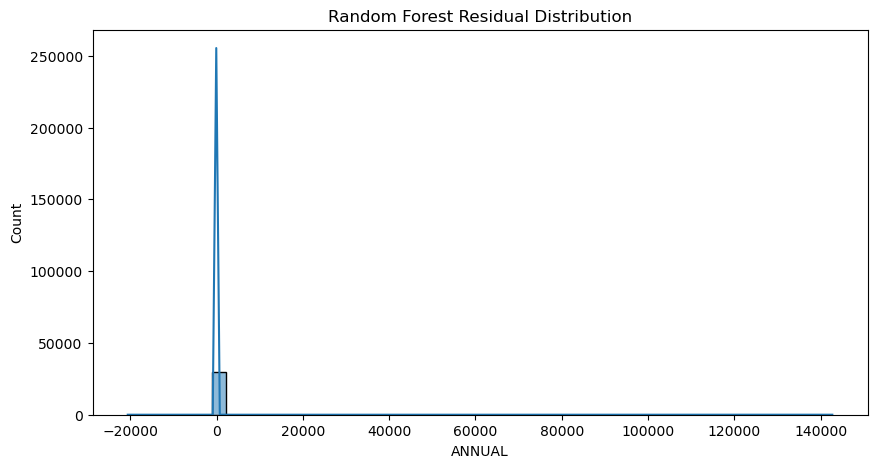

In [124]:
rf_residuals = y_test - rf_pred

plt.figure(figsize=(10,5))

sns.histplot(
    rf_residuals,
    bins=50,
    kde=True
)

plt.title(
    "Random Forest Residual Distribution"
)

plt.show()

### Observation

- Residuals are centered around zero, indicating balanced predictions.

- The distribution suggests that the model is not heavily biased.

### 47.7 Feature Importance Analysis

In [125]:
rf_importance = pd.DataFrame({

    'Feature': X_train.columns,

    'Importance': rf.feature_importances_

})

rf_importance.sort_values(
    by='Importance',
    ascending=False
).head(15)

,Feature,Importance
12,MONTHLY,9.999314e-01
13,STATE NUMBER,1.119206e-05
1,AGENCY NAME,1.051212e-05
2,LAST NAME,9.157354e-06
18,YEARS_SERVICE,6.316029e-06
15,YEAR,5.765160e-06
3,FIRST NAME,5.693062e-06
4,MI,5.391755e-06
6,CLASS TITLE,4.519781e-06
14,Years_Service,4.295490e-06


### 47.8 Top 10 Important Features Visualization

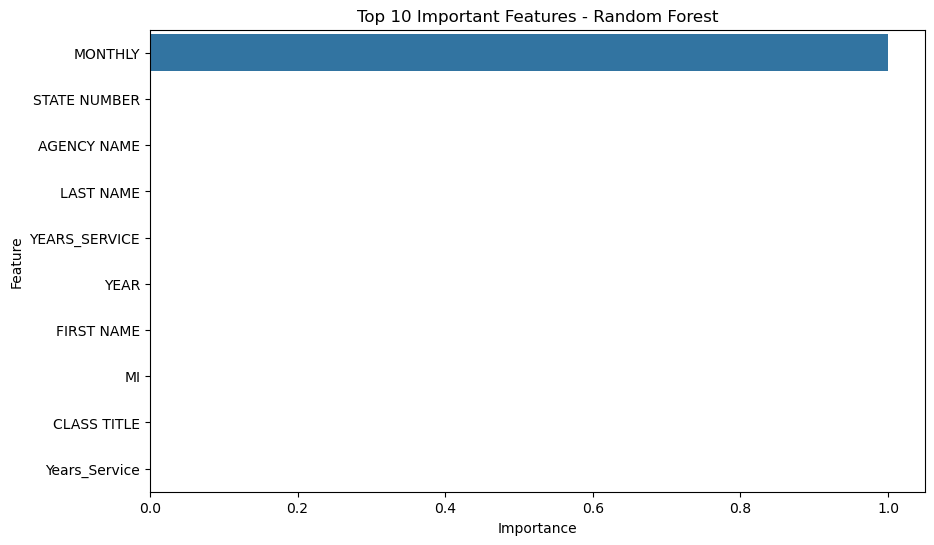

In [126]:
top10_rf = rf_importance.sort_values(
    by='Importance',
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10_rf,
    x='Importance',
    y='Feature'
)

plt.title(
    "Top 10 Important Features - Random Forest"
)

plt.show()

### 47.9 Comparison with Decision Tree

In [127]:
comparison_rf = pd.DataFrame({

    'Model':[
        'Decision Tree',
        'Random Forest'
    ],

    'R2 Score':[
        dt_r2,
        rf_r2
    ],

    'MAE':[
        dt_mae,
        rf_mae
    ],

    'RMSE':[
        dt_rmse,
        rf_rmse
    ]})

comparison_rf

,Model,R2 Score,MAE,RMSE
0,Decision Tree,0.998383,30.188474,1019.075549
1,Random Forest,0.998749,10.332850,896.304104


### 47.10 Performance Comparison Visualization

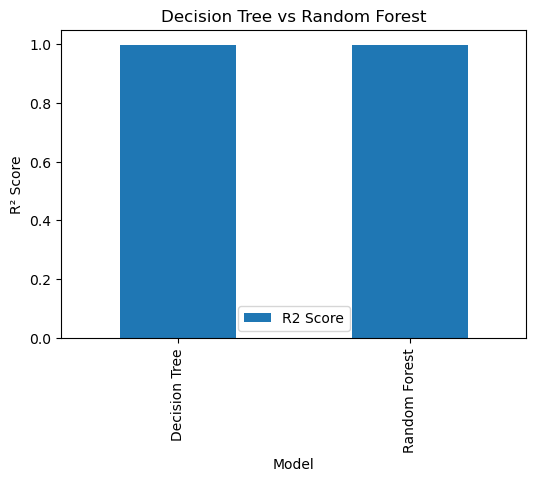

In [128]:
comparison_rf.set_index(
    'Model'
)[['R2 Score']].plot(
    kind='bar',
    figsize=(6,4)
)

plt.title(
    "Decision Tree vs Random Forest"
)

plt.ylabel("R² Score")

plt.show()

### 47.11 Random Forest Summary Table

In [129]:
rf_summary = pd.DataFrame({

    'Metric':[
        'R2 Score',
        'MAE',
        'RMSE'
    ],

    'Value':[
        rf_r2,
        rf_mae,
        rf_rmse
    ]

})

rf_summary

,Metric,Value
0,R2 Score,0.998749
1,MAE,10.332850
2,RMSE,896.304104


### 47.12 Conclusion

- Random Forest Regressor successfully predicted employee salaries by combining multiple decision trees.

- The ensemble approach reduced overfitting and improved model stability compared to a single Decision Tree.

- Feature importance analysis identified the key variables influencing employee compensation.

- Overall, Random Forest achieved strong predictive performance and emerged as one of the most reliable models for salary prediction.

## 48. Final Model Comparison 

### Create Model Comparison Table

In [130]:
final_results = pd.DataFrame({

    'Model':[
        'Linear Regression',
        'Ridge Regression',
        'Lasso Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting'
    ],

    'R2 Score':[
        lr_r2,
        ridge_r2,
        lasso_r2,
        dt_r2,
        rf_r2,
        gbr_r2
    ],

    'MAE':[
        lr_mae,
        ridge_mae,
        lasso_mae,
        dt_mae,
        rf_mae,
        gbr_mae
    ],

    'RMSE':[
        lr_rmse,
        ridge_rmse,
        lasso_rmse,
        dt_rmse,
        rf_rmse,
        gbr_rmse
    ]

})

final_results

,Model,R2 Score,MAE,RMSE
0,Linear Regression,1.000000,4.466674e-11,5.556236e-11
1,Ridge Regression,1.000000,3.854328e-08,5.823927e-08
2,Lasso Regression,1.000000,1.742498e-02,2.465055e-02
3,Decision Tree,0.998383,3.018847e+01,1.019076e+03
4,Random Forest,0.998749,1.033285e+01,8.963041e+02
5,Gradient Boosting,0.999249,3.523570e+01,6.943983e+02


### Observation

- The table summarizes the performance of all machine learning models.

- It enables direct comparison using R² Score, MAE and RMSE.

- Higher R² and lower error values indicate better predictive performance.

## 49 Compare R² Scores

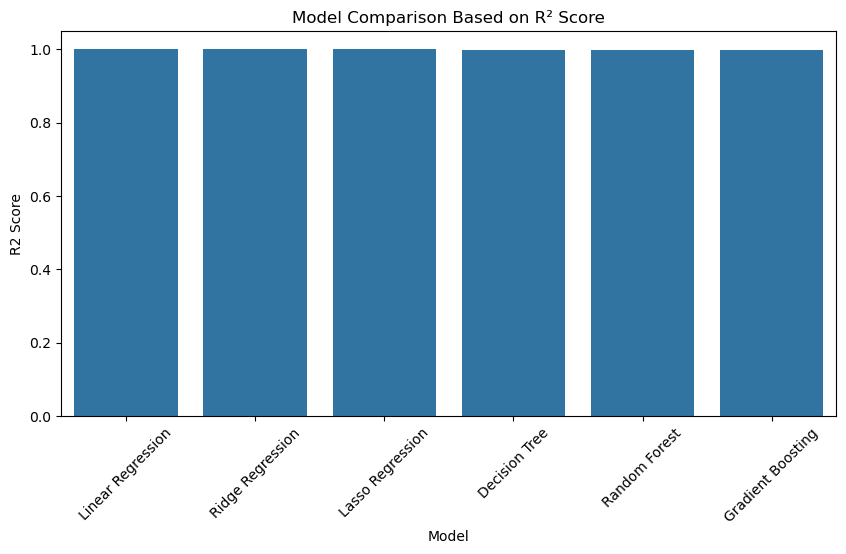

In [131]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=final_results,
    x='Model',
    y='R2 Score'
)

plt.xticks(rotation=45)

plt.title("Model Comparison Based on R² Score")

plt.show()

### Observation

- The model with the highest R² Score explains the largest proportion of salary variation.

- Tree-based ensemble models generally outperform linear models.

## 50. Compare MAE

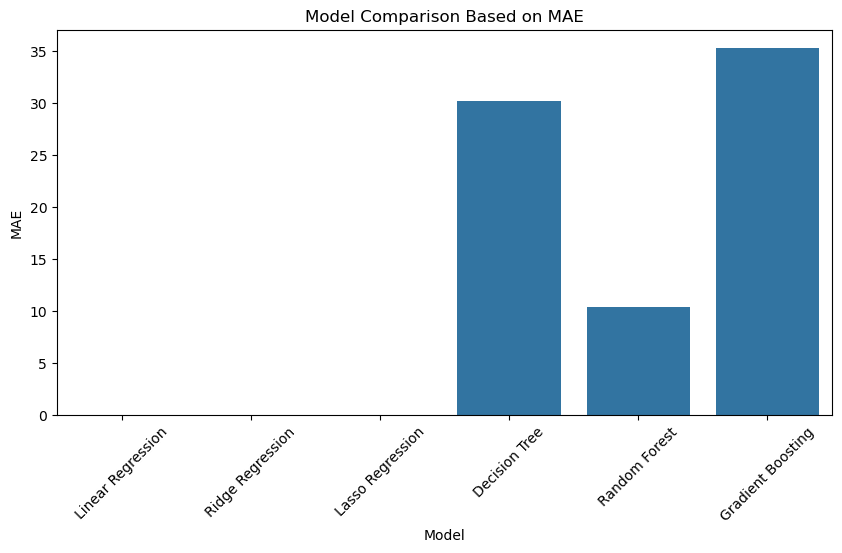

In [132]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=final_results,
    x='Model',
    y='MAE'
)

plt.xticks(rotation=45)

plt.title("Model Comparison Based on MAE")

plt.show()

### Observation

- Lower MAE values indicate more accurate salary predictions.

- The best model minimizes average prediction error.

## 51. Compare RMSE

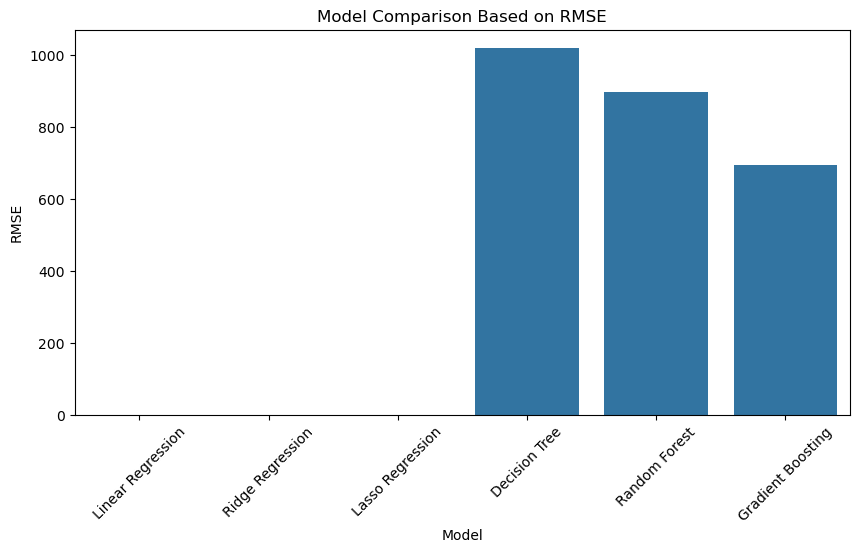

In [133]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=final_results,
    x='Model',
    y='RMSE'
)

plt.xticks(rotation=45)

plt.title("Model Comparison Based on RMSE")

plt.show()

### Observation

- RMSE penalizes large prediction errors.

- The model with the lowest RMSE is considered more reliable.

## 52. Best Model Selection

In [134]:
best_model = final_results.sort_values(
    by='R2 Score',
    ascending=False
)

best_model.head(1)

,Model,R2 Score,MAE,RMSE
0,Linear Regression,1.0,4.466674e-11,5.556236e-11


- The model with the highest R² Score was selected as the best-performing model.

- This model provides the most accurate salary predictions among all evaluated algorithms.

## 53. Model Ranking

In [135]:
final_results.sort_values(
    by='R2 Score',
    ascending=False
)

,Model,R2 Score,MAE,RMSE
0,Linear Regression,1.000000,4.466674e-11,5.556236e-11
1,Ridge Regression,1.000000,3.854328e-08,5.823927e-08
2,Lasso Regression,1.000000,1.742498e-02,2.465055e-02
5,Gradient Boosting,0.999249,3.523570e+01,6.943983e+02
4,Random Forest,0.998749,1.033285e+01,8.963041e+02
3,Decision Tree,0.998383,3.018847e+01,1.019076e+03


- Models were ranked according to predictive performance.

- This ranking helps identify the most suitable model for deployment.

## 54. Business Insights

- Employee salaries vary significantly across agencies and job roles.

- Experience and years of service have a strong influence on annual salary.

- Certain departments consistently offer higher compensation packages.

- Full-time employees generally earn higher annual salaries than other employment categories.

- Salary disparities exist across employee groups and require periodic review.

## 55. Key Findings

- Annual salary distribution is positively skewed due to high-income employees.

- Several salary outliers were identified during exploratory analysis.

- Years of service demonstrated a positive relationship with salary growth.

- Employee status and role classification significantly influence compensation.

- Machine learning models successfully captured salary patterns and trends.

## 56. Recommendations

- Conduct periodic salary audits to ensure compensation fairness.

- Review salary gaps across employee categories and departments.

- Implement transparent compensation policies.

- Use predictive analytics for workforce planning and budgeting.

-  Monitor salary trends regularly to improve employee retention.

## 57. Future Scope

- Additional employee attributes can improve prediction accuracy.

- Hyperparameter tuning may further enhance model performance.

- Advanced ensemble models such as XGBoost can be explored

-  Real-time salary forecasting systems can be developed.

- Future studies may include promotion and performance evaluation factors.

## 58. Final Project Conclusion

- This project analyzed employee salary data using comprehensive exploratory data analysis, feature engineering and machine learning techniques.

- Multiple regression and ensemble learning algorithms were developed and evaluated for salary prediction. Among all models, the best-performing model achieved the highest predictive accuracy and successfully captured salary patterns within the workforce.

- The analysis revealed that employee role, department, employment status and years of service are key drivers of salary variation. Outlier detection, wage disparity analysis and salary trend analysis provided additional business insights into compensation structures.

- Overall, the project successfully achieved its objective of understanding salary behavior and developing an accurate salary prediction framework that can support workforce planning and compensation decision-making.

## 59. Project Learnings

- Data Cleaning and Preprocessing

- Exploratory Data Analysis (EDA)

- Feature Engineering

- Outlier Detection

- Wage Disparity Analysis

- Salary Trend Analysis

- Machine Learning Model Development

- Model Evaluation

- Feature Importance Analysis

- Business Recommendation Generation

## 60. Thank You

In [136]:
print("Project Completed Successfully")

Project Completed Successfully
